# 03 — Hybrid Retrieval

## Dense + BM25 + Reciprocal Rank Fusion + Token-Aware Context Construction

Phase 3 upgrades the retrieval layer from a dense-only experiment into an inspectable, production-style hybrid retrieval architecture. This notebook is both an executable experiment and an engineering report. Reusable behavior remains in `src/cial_knowledge_os/`; the cells below configure, orchestrate, compare, and inspect that behavior.

**Status:** implemented, but not yet a frozen baseline. Full qualification against the unchanged 200-question CISG benchmark is still required.

> **How to use this notebook**
>
> Run the retrieval and visualization cells first. They require the approved local documents and cached embedding model, but no internet service. Answer generation requires the configured local Ollama model. The one-query artifact smoke run and the full benchmark are explicitly gated so a normal top-to-bottom run can skip extra generation calls.
>
> Phase 1, Phase 2, and the benchmark dataset are comparison baselines. This notebook does not rewrite them.

## 1. Objective

The Phase 3 question is: **does combining semantic and lexical retrieval improve evidence discovery without breaking the Phase 2 pipeline contract?**

The engineering goals are to:

- move from dense-only retrieval to configurable `dense`, `bm25`, or `hybrid` modes;
- combine semantic search with exact-term search for acronyms, identifiers, document titles, circular numbers, and section references;
- fuse incompatible result lists with Reciprocal Rank Fusion (RRF), not raw-score averaging;
- enforce context size in tokenizer units rather than approximate character counts;
- retain query transformations, deduplication, neighbor expansion, overlap merging, grounded generation, and safe failure from Phase 2;
- add clickable evidence navigation and isolated, reproducible run artifacts; and
- compare Phase 3 with the frozen Phase 2 baseline using the same corpus and benchmark.

A successful notebook run demonstrates the architecture and exposes its intermediate state. It does **not** by itself qualify Phase 3; qualification requires the controlled full benchmark described in Section 6.

### 1.1 Recap of the previous phases

| Phase | Retrieval and context behavior | What it established |
|---|---|---|
| **Phase 1 — Basic RAG** | PDF/text loading, metadata-aware chunking, local embeddings, embedded Qdrant, one dense query, grounded Ollama generation, citations | A transparent, fully offline RAG baseline |
| **Phase 2 — Query and context construction** | Deterministic query variants, multi-query dense retrieval, exact deduplication, neighbor expansion, overlap merging, character-bounded context, safe failure, evaluation traces | Better evidence collection and context construction without changing Phase 1 |
| **Phase 3 — Hybrid retrieval** | Dense + BM25 candidates, RRF, token-aware context, linked citations, structured run bundles | Better recall for semantic **and** exact evidence while preserving Phase 2 contracts |

The architectural boundary matters: Phase 3 replaces the candidate-retrieval layer and extends reporting, but it reuses the Phase 2 ingestion, chunking, transformation, post-processing, generation, and evaluation surfaces.

### 1.2 Why Phase 2 was not enough

Phase 2 improved a query before dense search, but every query variant still entered the same semantic retriever. That leaves several operational gaps:

1. **Exact identifiers can be under-ranked.** Dense embeddings may understand the topic while missing `AIBOM`, `CISG-2026-01`, a circular number, or `Section 7.3`.
2. **Rare vocabulary is not guaranteed to dominate semantic similarity.** A conceptually related chunk can outrank the only chunk containing the requested code.
3. **Characters are only a proxy for model input.** Phase 2's frozen character budget is deterministic, but LLM context limits are measured in tokens.
4. **CSV alone is inconvenient for evidence review.** Managers and reviewers benefit from linked spreadsheets, standalone HTML, structured JSON, retained context, figures, and logs.
5. **Citation metadata is not evidence navigation.** A source/page label is useful; a link to the local PDF page is faster to audit.

These are additions, not reasons to rewrite the baselines. Phase 1 and Phase 2 remain frozen so any gain or regression stays measurable.

## 2. Theory

### 2.1 Dense retrieval

Dense retrieval maps the query and every chunk into vectors. Similarity in the embedding space estimates conceptual relatedness, allowing different wording to match. For example, a chunk saying **“defend against prompt injection”** can match a query asking how to **“protect against malicious prompt manipulation.”**

This semantic tolerance is valuable for natural-language questions and paraphrases. Its weakness is that vector similarity does not guarantee exact matching of short, rare, or structured strings.

### 2.2 Lexical retrieval and BM25

Lexical retrieval scores literal token overlap. BM25 is a strong sparse-retrieval baseline because it balances three ideas:

- **Term frequency:** a query term occurring in a chunk is evidence of relevance, with diminishing returns for repetition.
- **Inverse document frequency:** rare terms such as `AIBOM` carry more information than common words such as “policy.”
- **Document-length normalization:** a match in a focused chunk should not be overwhelmed by a much longer chunk that happens to contain the term.

Conceptually, BM25 sums a length-normalized contribution for each query term:

$$
\operatorname{BM25}(q,d)=\sum_{t\in q}\operatorname{IDF}(t)\cdot
\frac{f(t,d)(k_1+1)}{f(t,d)+k_1\left(1-b+b\frac{|d|}{\operatorname{avgdl}}\right)}
$$

`k1` controls term-frequency saturation and `b` controls document-length normalization. Phase 3 keeps both values in typed configuration. BM25 is particularly useful for `AIBOM`, `CISG-2026-01`, `Section 7.3`, exact document names, and circular references.

### 2.3 Dense and BM25 are complementary

| Query pattern | Dense retrieval | BM25 retrieval |
|---|---|---|
| Semantic paraphrase | Usually strong even when wording changes | Depends on shared terms |
| Acronym or rare identifier | May understand the surrounding topic but miss the exact string | Strong when the literal token exists |
| Exact document title | Can retrieve conceptually related documents | Rewards title-token overlap |
| Regulatory or section reference | May blur nearby concepts | Preserves exact codes and numbers |
| Unsupported question | Still returns nearest neighbors | Still returns lexical matches if any |

Neither retriever proves that a question is answerable. They produce candidates; context construction, grounded prompting, and safe-failure behavior remain responsible for downstream evidence discipline.

### 2.4 Reciprocal Rank Fusion

Dense similarity and BM25 relevance use different score scales. A dense score of `0.78` and a BM25 score of `12.4` are not comparable, so averaging them would introduce an arbitrary calibration error.

RRF discards cross-retriever score magnitude and combines **rank positions**:

$$
\operatorname{RRF}(d)=\sum_{r\in R}\frac{w_r}{k+\operatorname{rank}_r(d)}
$$

- `R` is the set of retriever rankings in which document `d` appears.
- `w_r` is an optional positive retriever weight; Phase 3 defaults both modalities to `1.0`.
- `k` is the rank constant (`60` by default). A larger `k` softens the difference between adjacent ranks; a smaller value makes the top positions more dominant.

A chunk found by both retrievers accumulates contributions from both lists. A chunk found by only one modality can still survive. The fused result retains each modality's rank and raw score for auditability, while its public score becomes the RRF score. RRF is **fusion, not learned reranking**; relevance reranking remains Phase 4 work.

### 2.5 Token-aware context budgeting

LLMs consume tokens, not characters. Phase 1 and the frozen Phase 2 baseline use character limits; changing those notebooks would invalidate their comparison value. Phase 3 instead introduces a centralized token manager that counts, truncates, reports usage, and calculates remaining capacity through one interface.

The current packaged offline encoding is `cl100k_base`. It is deterministic and requires no network lookup, but it is **not Gemma-specific**. The tokenizer boundary is swappable so a validated model-specific tokenizer can replace it later without changing retrieval, context, evaluation, or reporting contracts. Setting `max_context_tokens=None` deliberately restores the Phase 2 character-fitting path while still reporting an exact centralized token count.

## 3. Architecture

The diagrams separate the frozen baseline, the Phase 3 flow, the fusion boundary, and the artifact boundary. Mermaid source is embedded directly in the notebook so the architecture remains reviewable offline in compatible notebook renderers.

### 3.1 Phase 2 baseline

```mermaid
flowchart TD
    Q[Question] --> QT[Query transformations]
    QT --> DR[Dense retrieval]
    DR --> DD[Deduplication]
    DD --> NE[Neighbor expansion]
    NE --> OM[Overlap merge]
    OM --> CB[Character-bounded context builder]
    CB --> LLM[Grounded local LLM]
    LLM --> C[Citations]
```

### 3.2 Phase 3 end-to-end flow

```mermaid
flowchart TD
    Q[Question] --> QT[Query transformations]
    QT --> HR[Dense retrieval + BM25 retrieval]
    HR --> RRF[Reciprocal Rank Fusion]
    RRF --> DD[Deduplication]
    DD --> NE[Neighbor expansion]
    NE --> OM[Overlap merge]
    OM --> TB[Token-aware context builder]
    TB --> LLM[Grounded local LLM]
    LLM --> C[Clickable citation builder]
    C --> A[Reproducible run artifacts]
```

### 3.3 Retrieval fusion boundary

```mermaid
flowchart LR
    V[Query variants] --> D[Dense result lists]
    V --> B[BM25 result lists]
    D --> F[RRF]
    B --> F
    F --> U[Unified ranked evidence with modality ranks and scores]
```

Each query variant is independently retrieved. Phase 2's evidence collection then combines the per-variant lists before exact deduplication and context construction. This means Phase 3 improves the retriever behind the existing multi-query contract rather than creating a second orchestration path.

### 3.4 Artifact boundary

```mermaid
flowchart TD
    R[Answer results and traces] --> CSV[results.csv]
    R --> XLSX[results.xlsx with citation hyperlinks]
    R --> HTML[standalone report.html]
    R --> JSON[config / summary / metrics / retrieval JSON]
    R --> CTX[per-question context exports]
    R --> FIG[figures]
    R --> LOG[structured logs]
```

`RunManager` owns directory creation and names. Notebook cells never construct competing artifact locations or overwrite previous runs.

## 4. Implementation

### 4.1 Local setup and imports

The project root is derived from the current working directory. This supports launching Jupyter from either the repository root or `notebooks/` and avoids machine-specific paths. The import cell includes only local project APIs plus standard analysis libraries.

In [1]:
from __future__ import annotations

import html
import json
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

WORKING_DIRECTORY = Path.cwd().resolve()
PROJECT_ROOT = (
    WORKING_DIRECTORY.parent
    if WORKING_DIRECTORY.name == "notebooks"
    else WORKING_DIRECTORY
)
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from cial_knowledge_os import (
    DenseRetriever,
    ExperimentGrid,
    ExperimentRunner,
    Phase3Config,
    Phase3RAGPipeline,
    Phase3Runner,
    ReciprocalRankFusion,
    ReconfiguringPipelineFactory,
    context_stage_counts_table,
    create_token_manager,
    load_benchmark,
    query_variants_table,
    retrieval_chunks_table,
    search_similar_chunks,
)

pd.set_option("display.max_colwidth", 120)
print(f"Project root: {PROJECT_ROOT}")
print("All inference and retrieval components are configured for local execution.")

Project root: E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS
All inference and retrieval components are configured for local execution.


### 4.2 Typed, path-safe configuration

Nothing below hardcodes a drive, model path, output folder, retrieval mode, token budget, or artifact filename. Important Phase 3 fields are:

- `retrieval_mode`: `dense`, `bm25`, `hybrid`, or an explicitly injected retriever;
- `dense_top_k` / `bm25_top_k`: per-modality candidate depths;
- `retrieval_top_k`: final result depth returned by one query variant;
- `rrf_k` and modality weights: rank-fusion behavior;
- `max_context_tokens`: enforced Phase 3 context budget;
- `neighbor_window`: source-relative expansion inherited from Phase 2;
- `bm25_cache_dir`, `qdrant_dir`, and `output_root`: resolved repository-local storage;
- `citation_link_mode`: local `file` links or a configured localhost document server; and
- `artifact_names`, logging settings, and run naming: the complete non-overwriting bundle contract.

The current API emits the complete bundle rather than exposing per-file artifact flags. This is intentional: a run should remain independently auditable.

In [2]:
config = Phase3Config(
    project_root=PROJECT_ROOT,
    retrieval_mode="hybrid",
    dense_top_k=10,
    bm25_top_k=10,
    retrieval_top_k=10,
    rrf_k=60,
    max_context_tokens=4096,
    neighbor_window=1,
)

config_table = pd.DataFrame(
    [
        ("retrieval_mode", config.retrieval_mode),
        ("dense_top_k", config.dense_top_k),
        ("bm25_top_k", config.bm25_top_k),
        ("retrieval_top_k", config.retrieval_top_k),
        ("rrf_k", config.rrf_k),
        ("max_context_tokens", config.max_context_tokens),
        ("tokenizer", config.tokenizer_encoding_name),
        ("neighbor_window", config.neighbor_window),
        ("qdrant_dir", config.qdrant_dir),
        ("bm25_cache_dir", config.bm25_cache_dir),
        ("output_root", config.output_root),
        ("phase_output_name", config.phase_output_name),
        ("citation_link_mode", config.citation_link_mode),
        ("structured_logging", config.structured_logging),
    ],
    columns=["setting", "effective_value"],
)
display(config_table)

,setting,effective_value
0,retrieval_mode,hybrid
1,dense_top_k,10
2,bm25_top_k,10
3,retrieval_top_k,10
4,rrf_k,60
5,max_context_tokens,4096
6,tokenizer,cl100k_base
7,neighbor_window,1
8,qdrant_dir,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\data\qdrant\cial_phase3
9,bm25_cache_dir,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\data\bm25\cial_phase3


### 4.3 Deterministic RRF micro-example

Before loading models, this small example verifies the most important fusion property: raw dense and BM25 scores remain separate, while ordering is determined by rank contributions. The code calls the production `ReciprocalRankFusion` implementation; it does not reimplement fusion in the notebook.

In [3]:
toy_chunks = {
    "semantic": {
        "text": "Defend systems against prompt injection.",
        "source": "ai-security.pdf",
        "page_number": 10,
        "chunk_id": "semantic",
        "score": 0.91,
    },
    "identifier": {
        "text": "AIBOM means Artificial Intelligence Bill of Materials.",
        "source": "bom-guideline.pdf",
        "page_number": 54,
        "chunk_id": "identifier",
        "score": 0.63,
    },
}

toy_fused = ReciprocalRankFusion(rank_constant=config.rrf_k).fuse(
    {
        "dense": [toy_chunks["semantic"], toy_chunks["identifier"]],
        "bm25": [
            {**toy_chunks["identifier"], "score": 12.4},
            {**toy_chunks["semantic"], "score": 2.1},
        ],
    }
)

display(
    pd.DataFrame(
        [
            {
                "fused_rank": rank,
                "chunk_id": item["chunk_id"],
                "rrf_score": item["rrf_score"],
                "dense_rank": item["retrieval_ranks"].get("dense"),
                "bm25_rank": item["retrieval_ranks"].get("bm25"),
                "dense_raw_score": item["retrieval_scores"].get("dense"),
                "bm25_raw_score": item["retrieval_scores"].get("bm25"),
            }
            for rank, item in enumerate(toy_fused, start=1)
        ]
    )
)

,fused_rank,chunk_id,rrf_score,dense_rank,bm25_rank,dense_raw_score,bm25_raw_score
0,1,semantic,0.032522,1,2,0.91,2.1
1,2,identifier,0.032522,2,1,0.63,12.4


### 4.4 Load, process, embed, and index the shared corpus

`Phase3RAGPipeline` inherits the proven Phase 2 ingestion and chunking lifecycle. One chunk corpus feeds both indexes:

1. `load()` extracts approved local PDF/text documents and metadata.
2. `chunk()` creates the shared evidence units.
3. `embed()` loads the configured local embedding model and embeds those chunks.
4. `index()` builds/reuses embedded Qdrant and builds/reuses the fingerprinted BM25 token cache.

Embedded Qdrant allows one process per storage path. Close another notebook kernel using the same collection before running this cell.

In [4]:
pipeline = Phase3RAGPipeline(config)

documents = pipeline.load()
chunks = pipeline.chunk()
chunk_vectors = pipeline.embed()
qdrant_client = pipeline.index()

lifecycle_summary = pd.DataFrame(
    [
        ("loaded documents", len(documents)),
        ("shared chunks", len(chunks)),
        ("dense vectors", len(chunk_vectors)),
        ("dense index ready", qdrant_client is not None),
        (
            "BM25 index ready",
            bool(pipeline.bm25_retriever and pipeline.bm25_retriever.is_indexed),
        ),
        ("BM25 indexing seconds", pipeline.metrics.get("bm25_indexing_time")),
    ],
    columns=["stage", "value"],
)
display(lifecycle_summary)

[INFO] 2026-07-03 21:31:06,352 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-03 21:31:06,371 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
docling_pdf_fallback
[INFO] 2026-07-03 21:31:06,996 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-03 21:31:06,997 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
docling_pdf_fallback
[INFO] 2026-07-03 21:31:07,079 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-03 21:31:07,080 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
docling_pdf_fallback
[INFO] 2026-07-03 21:31:07,209 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-03 21:31:07,211 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
docling_pdf_fallback
[INFO] 2026-07-03 21:31:07,336 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-03 21:31:07,337 [RapidOCR] device_config.py:64: Using GPU device with ID: 0
docling_pdf_fallback
[INFO] 2026-07-03 21:31:07,455 [RapidOCR] bas

Embedding device: cuda (TRANSFORMERS_OFFLINE=True, HF_HUB_OFFLINE=True)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\src\cial_knowledge_os\embeddings.py:69: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dimension = model.get_sentence_embedding_dimension()


,stage,value
0,loaded documents,394
1,shared chunks,1227
2,dense vectors,1227
3,dense index ready,True
4,BM25 index ready,True
5,BM25 indexing seconds,0.04725


### 4.5 Inspect the retriever composition

The dense adapter calls the existing Qdrant search function. The BM25 and hybrid retrievers were initialized by `pipeline.index()`. Creating the dense adapter here exposes each modality independently for the deep dive; it does not create another dense index.

In [5]:
dense_retriever = DenseRetriever(
    lambda query, top_k: search_similar_chunks(
        pipeline.client,
        query,
        pipeline.embedding_model,
        config,
        top_k=top_k,
    )
)
bm25_retriever = pipeline.bm25_retriever
hybrid_retriever = pipeline.hybrid_retriever

assert bm25_retriever is not None and bm25_retriever.is_indexed
assert hybrid_retriever is not None

retriever_table = pd.DataFrame(
    [
        (dense_retriever.name, config.dense_top_k, "Qdrant vectors", "semantic similarity"),
        (bm25_retriever.name, config.bm25_top_k, "shared chunk corpus", "exact lexical relevance"),
        (hybrid_retriever.name, config.retrieval_top_k, "dense + BM25 ranks", "RRF score"),
    ],
    columns=["retriever", "candidate_limit", "index_or_input", "ranking_signal"],
)
display(retriever_table)

,retriever,candidate_limit,index_or_input,ranking_signal
0,dense,10,Qdrant vectors,semantic similarity
1,bm25,10,shared chunk corpus,exact lexical relevance
2,hybrid,10,dense + BM25 ranks,RRF score


### 4.6 Single-query deep dive: “Where is AIBOM discussed?”

This representative query is intentionally short and identifier-heavy. We inspect:

- deterministic query transformations;
- the same original query through dense, BM25, and hybrid retrieval;
- overlap and modality contribution;
- RRF ranks and contributions;
- Phase 2-compatible post-retrieval stages;
- final token-aware context; and
- optional generation plus clickable citations.

The production pipeline still uses all configured query variants. The modality comparison first fixes the query text so differences come from the retrievers rather than from query transformation.

In [6]:
DEEP_DIVE_QUESTION = "Where is AIBOM discussed?"

query_variants = pipeline.transform_query(DEEP_DIVE_QUESTION)
display(query_variants_table(query_variants))

,variant_order,technique,query,changed_from_original,characters
0,1,original,Where is AIBOM discussed?,False,25
1,2,rewritten,Where is AIBOM discussed,True,24
2,3,domain_reformulation,"CIAL airport operations policy, SOP, manual, controls, responsibilities, and required actions: Where is AIBOM discussed",True,119


In [7]:
retrieval_latencies = {}

started = perf_counter()
dense_results = dense_retriever.retrieve(
    DEEP_DIVE_QUESTION,
    top_k=config.dense_top_k,
)
retrieval_latencies["dense"] = perf_counter() - started

started = perf_counter()
bm25_results = bm25_retriever.retrieve(
    DEEP_DIVE_QUESTION,
    top_k=config.bm25_top_k,
)
retrieval_latencies["bm25"] = perf_counter() - started

started = perf_counter()
hybrid_results = hybrid_retriever.retrieve(
    DEEP_DIVE_QUESTION,
    top_k=config.retrieval_top_k,
)
retrieval_latencies["hybrid"] = perf_counter() - started

print("Dense results")
display(retrieval_chunks_table(dense_results, stage="dense"))
print("BM25 results")
display(retrieval_chunks_table(bm25_results, stage="bm25"))
print("Hybrid fused results")
display(retrieval_chunks_table(hybrid_results, stage="hybrid"))

Dense results


,stage,rank,document,page,chunk_id,chunk_index,similarity_score,evidence_role,matched_queries,text_preview
0,dense,1,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,54,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p54:c184,184,0.564328,retrieved,,Version 2.0 Dated 09.07.2025 Page 53 9. Artificial Intelligence Bill of Materials (AIBOM) 9.1 What is Artificial Int...
1,dense,2,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,2,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p2:c7,7,0.558601,retrieved,,9. Artificial Intelligence Bill of Materials (AIBOM) ..................................................................
2,dense,3,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf,17,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p17:c49,49,0.553333,retrieved,,"systems, including smart contracts and infrastructure, to identify vulnerabilities, verify cryptographic integrity, ..."
3,dense,4,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,57,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p57:c195,195,0.549270,retrieved,,Version 2.0 Dated 09.07.2025 Page 56 9.4 Recommendations and Best Practices 9.4.1 Recommendations: 9.4.1.1 All gover...
4,dense,5,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,54,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p54:c187,187,0.541274,retrieved,,"the models, which is essential in fostering accountability. 9.2.3 Compliance: AIBOMs play a vital role in ensuring t..."
5,dense,6,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,58,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p58:c201,201,0.540257,retrieved,,vulnerability status information from VEXes to provide an up-to-date view of the AI system's vulnerability landscape...
6,dense,7,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,58,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p58:c199,199,0.539967,retrieved,,Version 2.0 Dated 09.07.2025 Page 57 9.4.1.7 AI developer/consumer/integrator organizations should integrate their A...
7,dense,8,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,54,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p54:c186,186,0.538369,retrieved,,significantly improve incident response by providing real-time insights into the status of components and materials ...
8,dense,9,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,57,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p57:c196,196,0.535670,retrieved,,"organizations must be accompanied by AIBOM, detailing the components and dependencies within the AI system. 9.4.1.3 ..."
9,dense,10,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,58,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p58:c202,202,0.533912,retrieved,,9.4.2 Best Practices: 9.4.2.1 Maintain a Comprehensive Inventory: The first step in creating AIBOM is to compile a c...


BM25 results


,stage,rank,document,page,chunk_id,chunk_index,similarity_score,evidence_role,matched_queries,text_preview
0,bm25,1,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,2,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p2:c7,7,9.259771,retrieved,,9. Artificial Intelligence Bill of Materials (AIBOM) ..................................................................
1,bm25,2,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,54,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p54:c184,184,8.252481,retrieved,,Version 2.0 Dated 09.07.2025 Page 53 9. Artificial Intelligence Bill of Materials (AIBOM) 9.1 What is Artificial Int...
2,bm25,3,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,57,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p57:c196,196,7.460325,retrieved,,"organizations must be accompanied by AIBOM, detailing the components and dependencies within the AI system. 9.4.1.3 ..."
3,bm25,4,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,58,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p58:c201,201,7.399170,retrieved,,vulnerability status information from VEXes to provide an up-to-date view of the AI system's vulnerability landscape...
4,bm25,5,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,31,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p31:c108,108,6.476765,retrieved,,SBOM data with vulnerability management and incident response processes c) Assign Roles and Ownership: Designate a c...
5,bm25,6,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,59,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p59:c203,203,6.447621,retrieved,,"Version 2.0 Dated 09.07.2025 Page 58 9.4.2.2 Standardized Format: Use standardized formats, like CycloneDX or SPDX, ..."
6,bm25,7,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,58,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p58:c200,200,6.306762,retrieved,,"solution supplier, ensuring full alignment with the system's components and their dependencies. 9.4.1.9 Security tea..."
7,bm25,8,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf,62,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p62:c174,174,6.204143,retrieved,,iii. Entry and Exit conferences should be organized and attended by the senior management of the auditee organizatio...
8,bm25,9,CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf,20,CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf:p20:c55,55,5.957949,retrieved,,"(AIBOM), Quantum Bill of Materials (QBOM), Cryptographic Bill of Materials (CBOM), and related xBOM mechanisms. Such..."
9,bm25,10,CISG-2025-01-Cyber Security Guidelines for Smart City Infrastructure.pdf,7,CISG-2025-01-Cyber Security Guidelines for Smart City Infrastructure.pdf:p7:c21,21,5.768583,retrieved,,interconnected sensors and devices creating an Internet of Everything. Understanding the threat landscape is vital f...


Hybrid fused results


,stage,rank,document,page,chunk_id,chunk_index,similarity_score,evidence_role,matched_queries,text_preview
0,hybrid,1,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,54,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p54:c184,184,0.032522,retrieved,,Version 2.0 Dated 09.07.2025 Page 53 9. Artificial Intelligence Bill of Materials (AIBOM) 9.1 What is Artificial Int...
1,hybrid,2,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,2,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p2:c7,7,0.032522,retrieved,,9. Artificial Intelligence Bill of Materials (AIBOM) ..................................................................
2,hybrid,3,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,58,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p58:c201,201,0.030777,retrieved,,vulnerability status information from VEXes to provide an up-to-date view of the AI system's vulnerability landscape...
3,hybrid,4,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,57,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p57:c196,196,0.030366,retrieved,,"organizations must be accompanied by AIBOM, detailing the components and dependencies within the AI system. 9.4.1.3 ..."
4,hybrid,5,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf,17,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p17:c49,49,0.015873,retrieved,,"systems, including smart contracts and infrastructure, to identify vulnerabilities, verify cryptographic integrity, ..."
5,hybrid,6,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,57,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p57:c195,195,0.015625,retrieved,,Version 2.0 Dated 09.07.2025 Page 56 9.4 Recommendations and Best Practices 9.4.1 Recommendations: 9.4.1.1 All gover...
6,hybrid,7,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,54,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p54:c187,187,0.015385,retrieved,,"the models, which is essential in fostering accountability. 9.2.3 Compliance: AIBOMs play a vital role in ensuring t..."
7,hybrid,8,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,31,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p31:c108,108,0.015385,retrieved,,SBOM data with vulnerability management and incident response processes c) Assign Roles and Ownership: Designate a c...
8,hybrid,9,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,59,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p59:c203,203,0.015152,retrieved,,"Version 2.0 Dated 09.07.2025 Page 58 9.4.2.2 Standardized Format: Use standardized formats, like CycloneDX or SPDX, ..."
9,hybrid,10,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,58,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p58:c199,199,0.014925,retrieved,,Version 2.0 Dated 09.07.2025 Page 57 9.4.1.7 AI developer/consumer/integrator organizations should integrate their A...


The next cells are presentation-only diagnostics. Canonical `(source, page, chunk_id)` identities expose which evidence is shared or unique, and the stored modality ranks make the RRF calculation auditable. Retrieval and fusion remain in project modules.

,evidence membership,chunk_count
0,dense only,6
1,BM25 only,6
2,both modalities,4
3,union,16


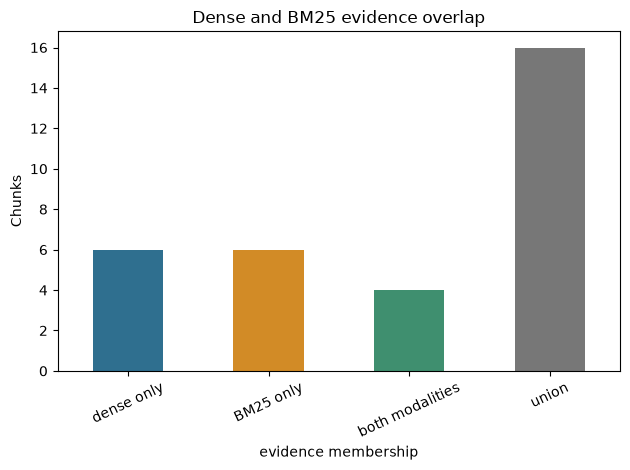

In [8]:
def evidence_identity(result):
    metadata = result.get("metadata") or {}
    return (
        str(metadata.get("source") or result.get("source") or ""),
        result.get("page_number") or metadata.get("page_number"),
        str(result.get("chunk_id") or metadata.get("chunk_id") or ""),
    )


dense_ids = {evidence_identity(item) for item in dense_results}
bm25_ids = {evidence_identity(item) for item in bm25_results}

overlap_table = pd.DataFrame(
    [
        ("dense only", len(dense_ids - bm25_ids)),
        ("BM25 only", len(bm25_ids - dense_ids)),
        ("both modalities", len(dense_ids & bm25_ids)),
        ("union", len(dense_ids | bm25_ids)),
    ],
    columns=["evidence membership", "chunk_count"],
)
display(overlap_table)

ax = overlap_table.set_index("evidence membership")["chunk_count"].plot.bar(
    title="Dense and BM25 evidence overlap",
    color=["#2f6f8f", "#d28b26", "#3f8f6f", "#777777"],
)
ax.set_ylabel("Chunks")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

In [9]:
rrf_rows = []
for fused_rank, item in enumerate(hybrid_results, start=1):
    ranks = item.get("retrieval_ranks") or {}
    dense_rank = ranks.get("dense")
    bm25_rank = ranks.get("bm25")
    dense_contribution = (
        config.dense_weight / (config.rrf_k + dense_rank)
        if dense_rank is not None
        else 0.0
    )
    bm25_contribution = (
        config.bm25_weight / (config.rrf_k + bm25_rank)
        if bm25_rank is not None
        else 0.0
    )
    metadata = item.get("metadata") or {}
    rrf_rows.append(
        {
            "fused_rank": fused_rank,
            "document": metadata.get("file_name") or item.get("source"),
            "page": item.get("page_number") or metadata.get("page_number"),
            "chunk_id": item.get("chunk_id") or metadata.get("chunk_id"),
            "dense_rank": dense_rank,
            "bm25_rank": bm25_rank,
            "dense_contribution": dense_contribution,
            "bm25_contribution": bm25_contribution,
            "calculated_rrf": dense_contribution + bm25_contribution,
            "stored_rrf": item.get("rrf_score"),
        }
    )

rrf_contribution_table = pd.DataFrame(rrf_rows)
display(rrf_contribution_table)

if not rrf_contribution_table.empty:
    assert (
        rrf_contribution_table["calculated_rrf"]
        .sub(rrf_contribution_table["stored_rrf"])
        .abs()
        .max()
        < 1e-12
    ), "Displayed RRF contributions do not match the production fuser."

print("The raw modality scores are retained for diagnosis but never averaged.")

,fused_rank,document,page,chunk_id,dense_rank,bm25_rank,dense_contribution,bm25_contribution,calculated_rrf,stored_rrf
0,1,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,54,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p54:c184,1.0,2.0,0.016393,0.016129,0.032522,0.032522
1,2,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,2,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p2:c7,2.0,1.0,0.016129,0.016393,0.032522,0.032522
2,3,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,58,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p58:c201,6.0,4.0,0.015152,0.015625,0.030777,0.030777
3,4,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,57,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p57:c196,9.0,3.0,0.014493,0.015873,0.030366,0.030366
4,5,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf,17,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p17:c49,3.0,NaN,0.015873,0.000000,0.015873,0.015873
5,6,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,57,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p57:c195,4.0,NaN,0.015625,0.000000,0.015625,0.015625
6,7,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,54,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p54:c187,5.0,NaN,0.015385,0.000000,0.015385,0.015385
7,8,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,31,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p31:c108,NaN,5.0,0.000000,0.015385,0.015385,0.015385
8,9,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,59,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p59:c203,NaN,6.0,0.000000,0.015152,0.015152,0.015152
9,10,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,58,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p58:c199,7.0,NaN,0.014925,0.000000,0.014925,0.014925


The raw modality scores are retained for diagnosis but never averaged.


### 4.7 Run the complete multi-query retrieval and context path

`pipeline.retrieve()` now applies all configured query variants. Each variant uses the selected hybrid retriever, after which the inherited Phase 2 orchestration collects and deduplicates candidate evidence. `ContextBuilder` then performs deduplication, neighbor expansion, overlap merging, and token-aware fitting. Calling the context builder directly here avoids an LLM call while exposing the exact evidence funnel.

In [10]:
deduplicated_retrieval = pipeline.retrieve(DEEP_DIVE_QUESTION)
context_result = pipeline.context_builder.build(
    pipeline.last_merged_retrieval,
    corpus_chunks=pipeline.chunks,
)

print("Deduplicated multi-query retrieval")
display(retrieval_chunks_table(deduplicated_retrieval, stage="deduplicated_retrieval"))

stage_frames = []
for stage_name in ("retrieved", "deduplicated", "expanded", "merged", "compressed"):
    stage_frames.append(
        retrieval_chunks_table(getattr(context_result, stage_name), stage=stage_name)
    )
context_evidence_table = pd.concat(stage_frames, ignore_index=True)
display(context_evidence_table)

context_tokens = pipeline.token_manager.count(context_result.context)
print(f"Final context: {len(context_result.context):,} characters / {context_tokens:,} tokens")
print(context_result.context[:2500])

Deduplicated multi-query retrieval


,stage,rank,document,page,chunk_id,chunk_index,similarity_score,evidence_role,matched_queries,text_preview
0,deduplicated_retrieval,1,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,2,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p2:c7,7,0.032787,retrieved,"original, rewritten",9. Artificial Intelligence Bill of Materials (AIBOM) ..................................................................
1,deduplicated_retrieval,2,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,54,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p54:c184,184,0.032522,retrieved,"original, rewritten",Version 2.0 Dated 09.07.2025 Page 53 9. Artificial Intelligence Bill of Materials (AIBOM) 9.1 What is Artificial Int...
2,deduplicated_retrieval,3,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,58,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p58:c201,201,0.030777,retrieved,"original, rewritten",vulnerability status information from VEXes to provide an up-to-date view of the AI system's vulnerability landscape...
3,deduplicated_retrieval,4,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,57,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p57:c196,196,0.030366,retrieved,"original, rewritten, domain_reformulation","organizations must be accompanied by AIBOM, detailing the components and dependencies within the AI system. 9.4.1.3 ..."
4,deduplicated_retrieval,5,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,57,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p57:c195,195,0.016393,retrieved,"original, rewritten, domain_reformulation",Version 2.0 Dated 09.07.2025 Page 56 9.4 Recommendations and Best Practices 9.4.1 Recommendations: 9.4.1.1 All gover...
5,deduplicated_retrieval,6,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf,46,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p46:c149,149,0.016393,retrieved,domain_reformulation,"manufacturers). Vendor Due Diligence: Require vendors to provide proof of security controls, especially for hardware..."
6,deduplicated_retrieval,7,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,54,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p54:c187,187,0.016129,retrieved,"original, rewritten, domain_reformulation","the models, which is essential in fostering accountability. 9.2.3 Compliance: AIBOMs play a vital role in ensuring t..."
7,deduplicated_retrieval,8,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,31,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p31:c108,108,0.016129,retrieved,"original, rewritten, domain_reformulation",SBOM data with vulnerability management and incident response processes c) Assign Roles and Ownership: Designate a c...
8,deduplicated_retrieval,9,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf,17,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p17:c49,49,0.015873,retrieved,"original, rewritten","systems, including smart contracts and infrastructure, to identify vulnerabilities, verify cryptographic integrity, ..."
9,deduplicated_retrieval,10,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf,18,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p18:c54,54,0.015873,retrieved,domain_reformulation,"Page 17 of 50 • Maintain Bill of Materials as per the technical guidelines on SBOM, QBOM & CBOM, AIBOM, HBOM issued ..."


,stage,rank,document,page,chunk_id,chunk_index,similarity_score,evidence_role,matched_queries,text_preview
0,retrieved,1,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,54,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p54:c184,184,0.032522,retrieved,original,Version 2.0 Dated 09.07.2025 Page 53 9. Artificial Intelligence Bill of Materials (AIBOM) 9.1 What is Artificial Int...
1,retrieved,2,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,2,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p2:c7,7,0.032522,retrieved,original,9. Artificial Intelligence Bill of Materials (AIBOM) ..................................................................
2,retrieved,3,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,58,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p58:c201,201,0.030777,retrieved,original,vulnerability status information from VEXes to provide an up-to-date view of the AI system's vulnerability landscape...
3,retrieved,4,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,57,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p57:c196,196,0.030366,retrieved,original,"organizations must be accompanied by AIBOM, detailing the components and dependencies within the AI system. 9.4.1.3 ..."
4,retrieved,5,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf,17,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p17:c49,49,0.015873,retrieved,original,"systems, including smart contracts and infrastructure, to identify vulnerabilities, verify cryptographic integrity, ..."
...,...,...,...,...,...,...,...,...,...,...
102,compressed,3,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,"56, 57, 58, 59",CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p56:c194 .. CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p59:c204,194,0.030777,added_neighbor,"original, rewritten, domain_reformulation","footprint. Vulnerabilities Known security vulnerabilities or weaknesses in the components, including severity rating..."
103,compressed,4,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf,"46, 47",CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p46:c148 .. CISG-2026-01-Cyber Securit...,148,0.016393,added_neighbor,domain_reformulation,"sovereignty, infrastructure protection, and incident reporting ☐ Full ☐ Partial ☐ No 1.3 Risk Assessment Conduct a c..."
104,compressed,5,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,31,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p31:c107 .. CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p31:c109,107,0.016129,added_neighbor,"original, rewritten, domain_reformulation","Version 2.0 Dated 09.07.2025 Page 30 Include cybersecurity specialists to provide expertise on secure data handling,..."
105,compressed,6,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf,"17, 18",CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p17:c48 .. CISG-2025-02-Comprehensive Cyber Security Audi...,48,0.015873,added_neighbor,"original, rewritten","configurations, patching, malware protection, encryption, access controls, and monitoring mechanisms to ensure robus..."


Final context: 18,777 characters / 4,095 tokens
[1]
Document: CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf
Page: 2, 3
Chunk ID: CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf:p2:c6 .. CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf:p3:c8
RRF Score: 0.033
8.1 What is Crypto & Quantum BOM? ............................................................................................ 42 
8.2 Benefits of Quantum and Crypto BOM ...................................................................................... 42 
8.3 Minimum elements of QBOM & CBOM ..................................................................................... 44 
8.4 Recommendations and Best Practices ...................................................................................... 48 
8.5 Quantum-Readiness and Migration Strategy ............................................................................. 51
9. Artificial Intelligence Bill of Materials (AIBOM) .............................................

### 4.8 Generate a grounded answer and render citations

This is the first cell that requires the configured local Ollama model. Retrieval is inspected before generation. If the local model is unavailable, the exception is recorded and later visualization cells continue using the already-built context. No hosted fallback is attempted.

In [11]:
response = None
generation_error = None

try:
    response = pipeline.answer(DEEP_DIVE_QUESTION)
except Exception as exc:
    generation_error = f"{type(exc).__name__}: {exc}"
    print("Local generation was not completed.")
    print(generation_error)

if response is not None:
    display(Markdown("#### Generated answer\n\n" + response["answer"]))
    display(
        pd.DataFrame(
            [
                {
                    "answer_status": response["answer_status"],
                    "retrieval_mode": response["retrieval_mode"],
                    **response["token_usage"],
                }
            ]
        )
    )

#### Generated answer

AIBOM (Artificial Intelligence Bill of Materials) is discussed in multiple documents:

*   **CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf:** This document dedicates a section to defining responsibilities, governance, and training related to AIBOM security.
*   **CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:** It's included as part of the auditing scope for evaluating transparency, traceability, and integrity of components used in AI systems.
*   **CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:** Mentions maintaining a Bill of Materials as per CERT-In guidelines, including AIBOM.

References:
[1] CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf | page 2, 3 | chunk CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf:p2:c6 .. CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf:p3:c8 | score 0.0328 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2024-02-%20SBOM%20%20AIBOM%20%20HBOM%20Version%202.0.pdf#page=2
[2] CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf | page 53, 54 | chunk CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf:p53:c183 .. CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf:p54:c188 | score 0.0325 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2024-02-%20SBOM%20%20AIBOM%20%20HBOM%20Version%202.0.pdf#page=53
[3] CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf | page 56, 57, 58, 59 | chunk CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf:p56:c194 .. CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf:p59:c204 | score 0.0308 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2024-02-%20SBOM%20%20AIBOM%20%20HBOM%20Version%202.0.pdf#page=56
[4] CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf | page 46, 47 | chunk CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p46:c148 .. CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p47:c150 | score 0.0164 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-01-Cyber%20Security%20Framework%20for%20Space%20%26%20Satellite%20Communication.pdf#page=46
[5] CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf | page 31 | chunk CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf:p31:c107 .. CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf:p31:c109 | score 0.0161 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2024-02-%20SBOM%20%20AIBOM%20%20HBOM%20Version%202.0.pdf#page=31
[6] CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf | page 17, 18 | chunk CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p17:c48 .. CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p18:c50 | score 0.0159 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2025-02-Comprehensive%20Cyber%20Security%20Audit%20Policy.pdf#page=17
[7] CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf | page 17, 18 | chunk CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p17:c53 .. CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p18:c55 | score 0.0159 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-01-Cyber%20Security%20Framework%20for%20Space%20%26%20Satellite%20Communication.pdf#page=17

,answer_status,retrieval_mode,budget,used,remaining,context_tokens,encoding_name,truncated_sections,omitted_sections,budget_type
0,answered,hybrid,4096,4095,1,4095,cl100k_base,1,3,tokens


In [12]:
if response is None:
    display(Markdown("_Citations require a successful local generation run._"))
else:
    citation_table = pd.DataFrame(response["citations"])
    display(citation_table)
    if response["citations"]:
        citation_items = []
        for citation in response["citations"]:
            label = html.escape(
                f"[{citation['reference_id']}] {citation.get('source_file') or citation.get('source')} "
                f"— page {citation.get('page_number')}"
            )
            link = citation.get("pdf_link")
            citation_items.append(
                f'<li><a href="{html.escape(str(link), quote=True)}" target="_blank">{label}</a></li>'
                if link
                else f"<li>{label} (no portable PDF link)</li>"
            )
        display(HTML("<h4>Clickable evidence</h4><ol>" + "".join(citation_items) + "</ol>"))

,reference_id,source,page_number,chunk_id,score,source_file,source_path,pdf_link
0,1,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,"2, 3",CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p2:c6 .. CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p3:c8,0.032787,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\data\pdf\CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2024-02-%20SBOM%20%20AIBOM%20%20HBOM%20Version%2...
1,2,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,"53, 54",CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p53:c183 .. CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p54:c188,0.032522,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\data\pdf\CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2024-02-%20SBOM%20%20AIBOM%20%20HBOM%20Version%2...
2,3,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,"56, 57, 58, 59",CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p56:c194 .. CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p59:c204,0.030777,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\data\pdf\CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2024-02-%20SBOM%20%20AIBOM%20%20HBOM%20Version%2...
3,4,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf,"46, 47",CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p46:c148 .. CISG-2026-01-Cyber Securit...,0.016393,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\data\pdf\CISG-2026-01-Cyber Security Framework for Space & Satellite Com...,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-01-Cyber%20Security%20Framework%20for%20Spa...
4,5,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,31,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p31:c107 .. CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p31:c109,0.016129,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\data\pdf\CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2024-02-%20SBOM%20%20AIBOM%20%20HBOM%20Version%2...
5,6,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf,"17, 18",CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p17:c48 .. CISG-2025-02-Comprehensive Cyber Security Audi...,0.015873,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\data\pdf\CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2025-02-Comprehensive%20Cyber%20Security%20Audit...
6,7,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf,"17, 18",CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p17:c53 .. CISG-2026-01-Cyber Security...,0.015873,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\data\pdf\CISG-2026-01-Cyber Security Framework for Space & Satellite Com...,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-01-Cyber%20Security%20Framework%20for%20Spa...


## Interactive Manual QA

Use this section for ad hoc questions after the Phase 3 pipeline has been loaded and indexed. Edit the Python list in the next cell, then run the input, execution, and display cells in order.

The workflow supports one or many questions and deliberately uses `Phase3Runner` rather than a notebook-side answer loop. Every valid manual run therefore produces the standard non-overwriting Phase 3 bundle: CSV, XLSX, standalone HTML, configuration, summary, metrics, retrieval JSON, structured logs, latency figure, and per-question context exports.

Manual settings temporarily override the active pipeline and are restored after the run. Candidate depths, RRF settings, model names, citation behavior, and operational paths continue to come from `config`. Blank entries are ignored. If no usable questions remain, no empty artifact run is created.

In [13]:
# Edit this list and rerun the next two cells.
'''
manual_questions = [

    # =========================
    # Vendor & Procurement
    # =========================

    "We're evaluating a new software vendor. What cybersecurity evidence should we request before approving their product?",
    "A vendor has provided us with an SBOM. What should our security team verify before deployment?",
    "What cybersecurity requirements should be included in contracts with software vendors?",
    "How should we evaluate the cybersecurity maturity of a new technology supplier?",
    "A vendor cannot release a security patch immediately. What compensating controls should we implement?",
    "What information should OEMs provide after discovering a critical vulnerability?",
    "How should we assess third-party AI providers before integrating their services?",
    "What documentation should cloud service providers provide to demonstrate security compliance?",
    "How can we verify that a vendor follows secure software development practices?",
    "Which supply chain security controls should be mandatory for critical vendors?",

    # =========================
    # AI Security
    # =========================

    "We're planning to deploy an AI-powered assistant. What cybersecurity controls should we implement before going live?",
    "How can we protect our AI chatbot against prompt injection attacks?",
    "What are the biggest cybersecurity risks of deploying generative AI internally?",
    "How should AI systems be monitored after deployment?",
    "What governance policies should be established before employees start using AI tools?",
    "How should AI-related risks be incorporated into our enterprise risk management process?",
    "What security controls should protect AI APIs exposed to the internet?",
    "How should we validate the security of AI-generated outputs?",
    "How can attackers misuse AI against our organization?",
    "What defensive measures does CERT-In recommend against AI-assisted cyber attacks?",

    # =========================
    # Incident Response
    # =========================

    "Our SOC has detected suspicious activity on an internet-facing server. What should we do first?",
    "We suspect one of our systems has been compromised. What immediate actions should we take?",
    "How should we respond if ransomware is detected in our environment?",
    "What information should be collected during a cybersecurity incident investigation?",
    "How should incidents be escalated within the organization?",
    "When should cybersecurity incidents be reported to CERT-In?",
    "What logs should be preserved after a security incident?",
    "How should executive management be informed during major cyber incidents?",
    "What should be included in our incident response playbook?",
    "How can we improve cyber resilience after recovering from an incident?",

    # =========================
    # Vulnerability Management
    # =========================

    "A new critical vulnerability has been announced. How should we prioritize our response?",
    "How should vulnerability remediation be prioritized across multiple systems?",
    "What is the recommended patch management process?",
    "How should exposed internet-facing services be managed?",
    "How frequently should vulnerability assessments be performed?",
    "What should we do if a zero-day vulnerability affects one of our systems?",
    "How should vulnerability scanning results be validated?",
    "What metrics should management monitor for vulnerability management?",
    "How should attack surface management be implemented?",
    "How should continuous exposure management be performed?",

    # =========================
    # Governance
    # =========================

    "What cybersecurity governance structure should our organization establish?",
    "How should executive leadership oversee cybersecurity risks?",
    "What cybersecurity policies should every organization maintain?",
    "How should AI governance be implemented across the organization?",
    "How should cybersecurity responsibilities be assigned across departments?",
    "What governance controls should protect critical infrastructure?",
    "How should cyber risks be reported to senior management?",
    "What security metrics should be presented to leadership regularly?",
    "How should cybersecurity governance evolve as threats change?",
    "What continuous improvement activities should be part of cybersecurity governance?",

    # =========================
    # Audits & Compliance
    # =========================

    "We're preparing for our annual cybersecurity audit. What areas should we review first?",
    "What evidence should we prepare before auditors arrive?",
    "How should cybersecurity audit findings be prioritized?",
    "What documentation should be retained after completing an audit?",
    "How should source code be reviewed during security assessments?",
    "How should cloud environments be evaluated during audits?",
    "What cybersecurity controls should auditors validate independently?",
    "How should AI systems be included in cybersecurity audits?",
    "What are the responsibilities of our organization during a CERT-In audit?",
    "How should corrective actions from previous audits be tracked?",

    # =========================
    # Security Operations
    # =========================

    "How should continuous security monitoring be implemented across the organization?",
    "What security events should our SOC prioritize?",
    "How should threat intelligence improve our security operations?",
    "How can automation improve cyber defense without reducing oversight?",
    "What Zero Trust practices should we implement first?",
    "How should privileged access be managed?",
    "What identity security controls are considered essential?",
    "How should sensitive organizational data be protected throughout its lifecycle?",
    "How should network segmentation be implemented for critical systems?",
    "How should security validation become a continuous process instead of a periodic activity?",

    # =========================
    # Executive & Enterprise
    # =========================

    "Summarize the highest-priority cybersecurity recommendations our organization should implement this year.",
    "If our organization could only implement five cybersecurity improvements, what should they be?",
    "Prepare a cybersecurity roadmap for strengthening our organization's overall security posture.",
    "Summarize the major recommendations across all the indexed CERT-In publications.",
    "How do the different CERT-In guidelines complement each other when building an enterprise cybersecurity program?"
]

manual_questions.extend([

    # =========================
    # Paraphrase & Synonym Stress Tests
    # =========================

    "We're worried about attackers using AI to speed up cyber attacks. What protections should we put in place?",
    "How do we reduce the risk from AI-powered hacking attempts?",
    "What should we do to defend against automated cyber exploitation?",
    "How can we make our systems harder for attackers using AI tools to exploit?",
    "What controls help us respond faster when vulnerabilities are discovered?",
    "How should we handle security weaknesses before attackers find them?",
    "What should our team do to reduce exposed services and misconfigured systems?",
    "How can we improve our readiness against fast-moving cyber threats?",
    "What does CERT-In recommend for reducing our attack surface?",
    "How should we strengthen our defenses against phishing that looks highly personalized?",

    # =========================
    # Acronym & Terminology Queries
    # =========================

    "A vendor mentioned SBOM in a proposal. What does it mean and why should we care?",
    "Someone asked for an AIBOM for an AI system. What should that contain?",
    "What is the practical difference between SBOM, AIBOM, and HBOM for our procurement team?",
    "What does CVSS tell us when we review vulnerabilities?",
    "How is EPSS useful when deciding which vulnerabilities to fix first?",
    "What does TT&C mean in satellite communication security?",
    "What is Zero Trust and how would it apply to our airport systems?",
    "What is privileged access management and why is it important?",
    "What is micro-segmentation and where should we use it?",
    "What does secure-by-design mean for applications we build or buy?",

    # =========================
    # Cross-Document Comparison
    # =========================

    "Compare the CISG guidance for AI security with the guidance for secure application development.",
    "How do the audit guidelines and OEM guidelines differ in their approach to vulnerability management?",
    "Compare the MSME baseline controls with the broader government information security guidelines.",
    "How do the smart city cybersecurity guidelines relate to airport digital infrastructure?",
    "Compare the space cybersecurity guidance with the smart city guidance for protecting critical infrastructure.",
    "How do the SBOM guidelines support the OEM vulnerability response requirements?",
    "Compare the incident reporting expectations across the MSME, OEM, and space cybersecurity documents.",
    "How do Zero Trust recommendations appear across the AI, space, and smart city guidance?",
    "Compare secure-by-design guidance across applications, AI systems, and satellite communication systems.",
    "How do the different documents approach third-party and supply-chain risk?",

    # =========================
    # Multi-Hop Reasoning
    # =========================

    "If we deploy a vendor-supplied AI application, what should we check across AI governance, SBOM, vendor risk, and incident response?",
    "If a critical vulnerability is found in a third-party product used in airport operations, what should our security and procurement teams do?",
    "If we are setting up a new command-and-control style monitoring centre, what cybersecurity guidance should we follow?",
    "If a supplier provides software, firmware, cloud APIs, and AI features, what security documents and controls should we ask for?",
    "If our AI system connects to operational infrastructure, what risks should we assess before deployment?",
    "If an audit finds weak logging and poor patch management, what corrective actions should we prioritize?",
    "If a system uses open-source components, AI models, and hardware devices, what Bills of Materials should we maintain?",
    "If we detect suspicious privileged-user behavior, which logging, monitoring, and access controls should apply?",
    "If a contractor needs temporary access to internal systems, what access and vendor-risk controls should we enforce?",
    "If a cybersecurity incident involves a vendor product, what should both our organization and the vendor do?",

    # =========================
    # Ambiguous Queries
    # =========================

    "What should we do about monitoring?",
    "How should we handle access?",
    "What controls are needed for vendors?",
    "What should we review before deployment?",
    "How do we improve resilience?",
    "What needs to be reported?",
    "What should be encrypted?",
    "How should we manage risk?",
    "What should be tested regularly?",
    "What should leadership review?",

    # =========================
    # Enumeration / List Questions
    # =========================

    "List the main cybersecurity controls we should implement as a baseline.",
    "List the key governance measures recommended for AI-assisted cyber threats.",
    "List the major categories of cybersecurity audits covered by CERT-In.",
    "List the key steps we should follow when responding to a cyber incident.",
    "List the main supply-chain security practices recommended across the documents.",
    "List the essential controls for securing remote access.",
    "List the most important logging and monitoring recommendations.",
    "List the main security checks before releasing or deploying software.",
    "List the major threats to satellite communication systems.",
    "List the key components that should be considered in a secure application lifecycle.",

    # =========================
    # Numeric / Specific Fact Questions
    # =========================

    "How quickly should cyber incidents be reported to CERT-In?",
    "How long should security logs be retained?",
    "How often should internal cybersecurity audits be conducted?",
    "How often should external cybersecurity audits be conducted?",
    "What CVSS range is considered critical?",
    "What CVSS range is considered high severity?",
    "How often should employees receive basic cybersecurity awareness training?",
    "What patch timelines are recommended for critical vulnerabilities that could likely be exploited using AI?",
    "What patch timelines are recommended for high-severity vulnerabilities?",
    "What minimum log retention expectations appear in the guidelines?",

    # =========================
    # Negative / Unsupported Questions
    # =========================

    "What is the approved cybersecurity budget for CIAL next year?",
    "Which specific firewall brand does CERT-In require us to buy?",
    "Which LLM vendor does CERT-In officially recommend for airport AI systems?",
    "What is the exact number of cybersecurity staff CIAL must hire?",
    "What is tomorrow's stock market prediction for Indian IT companies?",
    "Which employee at CIAL should be appointed as CISO?",
    "What is the cafeteria menu for next Monday?",
    "What is the exact cost of implementing all CISG recommendations at CIAL?",
    "Which cloud provider does CERT-In mandate for all organizations?",
    "What is the password of the airport network administrator account?",

    # =========================
    # Fuzzy / Typo-Like Questions
    # =========================

    "How should we handle vulnerablity management?",
    "What are the securty controls for AI systems?",
    "How should we protect satelite communication links?",
    "What loggin and monitoring practices are recommended?",
    "How should we manage third party cybersecuirty risk?",

])
'''

manual_questions = [

    # =========================
    # Role-Based CIAL Staff Questions
    # =========================

    "As the CISO, what should I prioritize first from the CERT-In guidance?",
    "As an IT administrator, what daily or weekly cybersecurity practices should I follow?",
    "As a procurement officer, what cybersecurity checks should I perform before onboarding a vendor?",
    "As an airport operations manager, what cyber risks should I consider when deploying connected infrastructure?",
    "As a SOC analyst, what should I monitor for AI-assisted cyber threats?",
    "As a software project owner, what should I ask developers to prove before production deployment?",
    "As a network engineer, what segmentation controls should I implement for sensitive systems?",
    "As an executive, what cybersecurity risks require board-level visibility?",
    "As an audit coordinator, what evidence should I collect before a third-party cybersecurity audit?",
    "As a vendor manager, how should I evaluate whether a supplier is following CERT-In guidance?",

    # =========================
    # Secure Application Development
    # =========================

    "We're building an internal application. What security practices should be included from the design stage?",
    "Why is relying only on post-development security audits not enough?",
    "What secure development practices should our software team follow?",
    "How should authentication, authorization, and session management be handled in applications?",
    "What cryptographic practices should developers follow?",
    "How should source code changes be controlled and reviewed?",
    "How should input validation be implemented to prevent injection attacks?",
    "What should developers do to prevent memory and file handling vulnerabilities?",
    "How should threat modelling be used during application development?",
    "What security testing should happen before deploying an application to production?",

    # =========================
    # Network & Infrastructure Security
    # =========================

    "How should we design our network perimeter to reduce cyber risk?",
    "Why should different airport systems be placed in separate network segments?",
    "What firewall practices should be followed for internal and external networks?",
    "How should IDS, IPS, NDR, XDR, and firewalls be used together?",
    "How should DNS be configured securely inside the organization?",
    "Why should proxy servers be used for internet access?",
    "What logs from perimeter security devices should be integrated with SIEM?",
    "How should VPN access be secured for remote users?",
    "What should we do about remote desktop tools like AnyDesk or TeamViewer?",
    "How should guest Wi-Fi be separated from internal networks?",

    # =========================
    # Wireless, BYOD, and Endpoint Controls
    # =========================

    "What precautions should we take before allowing personal devices on the network?",
    "How should Wi-Fi access points be configured securely?",
    "Should open wireless access points be allowed in our network?",
    "How should guest WLAN access be designed for visitors?",
    "How should we prevent bridging between wired and wireless networks?",
    "What should we do to detect rogue access points?",
    "How should endpoints be checked before being allowed on the network?",
    "What host firewall controls should be enabled on user systems?",
    "How should USB and removable media usage be controlled?",
    "What should we do about pirated or unauthorized software on employee devices?",

    # =========================
    # Data Protection, Logs, and Backups
    # =========================

    "How should sensitive organizational data be classified and protected?",
    "What backup practices should we follow for critical applications?",
    "How should backup copies be stored securely?",
    "How often should backup restoration be tested?",
    "What should be included in a minimum business continuity plan?",
    "How should security logs be protected from tampering?",
    "What systems should have comprehensive logging enabled?",
    "How should privileged user activity be monitored?",
    "What evidence should be preserved for forensic investigation?",
    "How should operational data be protected when using cloud or AI systems?",

    # =========================
    # Smart Infrastructure / Airport-Like Systems
    # =========================

    "We're deploying smart cameras and sensors across airport premises. What cybersecurity risks should we consider?",
    "How should command-and-control systems for smart infrastructure be secured?",
    "How can we prevent attackers from moving laterally from IoT devices into critical systems?",
    "What risks exist if CCTV systems are compromised?",
    "What risks exist if access control or parking systems are poorly secured?",
    "How should traffic or transport-related digital systems be protected from cyber disruption?",
    "What cybersecurity controls should be applied to public-facing digital services?",
    "How should data centres supporting smart infrastructure be protected?",
    "Why is segmentation especially important for smart infrastructure?",
    "How should smart infrastructure be designed for resilience and continuity?",

    # =========================
    # Satellite / Communication Systems
    # =========================

    "If CIAL uses satellite communication links, what cybersecurity risks should we assess?",
    "How should command uplinks be protected from unauthorized access?",
    "How should telemetry and communication links be secured?",
    "What should we monitor to detect anomalies in satellite communication systems?",
    "How should ground station networks be protected?",
    "What security controls should apply to user terminals connected to satellite networks?",
    "How should satellite communication providers handle incident reporting?",
    "What governance role should a CSSO or CISO play in space-related systems?",
    "How should supply chain risks be handled for satellite communication equipment?",
    "Why is space cybersecurity treated differently from normal IT security?",

    # =========================
    # Supply Chain and Bills of Materials
    # =========================

    "Why should we ask vendors for a Software Bill of Materials during procurement?",
    "How does an SBOM help us respond faster to vulnerabilities?",
    "What should an SBOM contain at minimum?",
    "How should SBOMs be updated when software changes?",
    "What is the difference between a top-level SBOM and a complete SBOM?",
    "When should we ask for an AIBOM instead of only an SBOM?",
    "When is an HBOM useful for our organization?",
    "How should Bills of Materials support vulnerability tracking?",
    "How should SBOMs be shared securely with consumers?",
    "How can SBOM adoption improve software supply chain transparency?",

    # =========================
    # Harder Cross-Document Synthesis
    # =========================

    "If we deploy a smart AI-enabled surveillance system, which CERT-In documents are most relevant and why?",
    "How should we combine secure application development, AI governance, and vendor risk controls for a new AI application?",
    "How do audit evidence, SBOMs, and vulnerability remediation plans support each other?",
    "What controls should be implemented when a third-party product connects to critical airport infrastructure?",
    "How do continuous monitoring, incident response, and vulnerability management work together?",
    "What should our organization do differently if a vulnerability is likely to be exploited using AI?",
    "How should procurement, IT, and SOC teams coordinate during vendor onboarding?",
    "How should cybersecurity responsibilities be split between our organization and an OEM vendor?",
    "What guidance applies when a vendor product includes software, hardware, cryptography, and AI components?",
    "How can we build a single cybersecurity roadmap using the government, MSME, AI, audit, and OEM guidance?",

]

'''
manual_questions.extend([

    # =========================
    # Retrieval Stress Tests
    # =========================

    "Show me every recommendation related to Zero Trust across all CERT-In publications.",
    "Find every mention of SBOM across the indexed documents.",
    "List every recommendation related to AI governance.",
    "Find all guidance related to incident response.",
    "Show every recommendation involving supply chain security.",
    "List every recommendation for continuous monitoring.",
    "Find every recommendation involving third-party vendors.",
    "Show all recommendations related to cloud security.",
    "List every recommendation related to vulnerability management.",
    "Find all references to privileged access management.",

    # =========================
    # Large Context / Compression
    # =========================

    "Prepare an executive briefing summarizing the complete CERT-In cybersecurity strategy for a large enterprise.",
    "Summarize all recommendations for reducing cyber risk across every indexed document.",
    "Prepare a comprehensive cybersecurity roadmap for CIAL using all available CERT-In guidance.",
    "Summarize every governance recommendation across all publications.",
    "Summarize every AI-related recommendation across the corpus.",
    "Summarize every recommendation related to supply chain security.",
    "Prepare an implementation roadmap for an organization beginning its cybersecurity journey.",
    "Summarize all recommendations applicable to critical infrastructure operators.",
    "Prepare a management presentation summarizing the most important cybersecurity priorities.",
    "Summarize every recommendation related to operational resilience.",

    # =========================
    # Retrieval Ordering
    # =========================

    "What are the most important cybersecurity controls we should implement immediately?",
    "Rank the most critical cybersecurity recommendations from highest to lowest priority.",
    "Which recommendations should be implemented first for maximum risk reduction?",
    "Which controls provide the greatest improvement to cybersecurity maturity?",
    "What should be considered our top priorities before deploying new technology?",
    "Which vulnerabilities deserve immediate attention?",
    "Which governance controls are considered foundational?",
    "Which security controls should be implemented before advanced monitoring?",
    "What recommendations are considered mandatory versus recommended?",
    "How should cybersecurity investments be prioritized?",

    # =========================
    # Executive Decision Making
    # =========================

    "Our board wants a one-page cybersecurity strategy. What should it contain?",
    "If we had only six months to improve cybersecurity, what should we focus on?",
    "Where should management invest first to reduce organizational cyber risk?",
    "What cybersecurity gaps are most likely to expose critical infrastructure?",
    "How can executive leadership measure cybersecurity maturity?",
    "How should executives track cybersecurity performance over time?",
    "Which cybersecurity metrics should appear in quarterly board meetings?",
    "What risks should executives never ignore?",
    "How should leadership balance security with operational continuity?",
    "What governance activities require executive oversight?",

    # =========================
    # Scenario-Based Questions
    # =========================

    "A vendor informs us that one of their products contains a newly discovered critical vulnerability. What should we do?",
    "An AI application used internally has become vulnerable to prompt injection. What actions should we take?",
    "An employee accidentally exposes sensitive credentials. What guidance applies?",
    "We discover that a contractor has excessive privileged access. What controls should we review?",
    "Our vulnerability scan identified hundreds of issues. How should we prioritize remediation?",
    "A supplier refuses to provide an SBOM. What risks should we consider?",
    "A software dependency becomes compromised. How should we respond?",
    "An AI-powered phishing campaign is targeting employees. What defensive measures should we implement?",
    "A cloud-hosted application is found to have insecure API configurations. What recommendations apply?",
    "Our disaster recovery test failed. What resilience improvements should we make?",

    # =========================
    # Edge Cases
    # =========================

    "What cybersecurity guidance applies to quantum computing systems?",
    "What recommendations apply to cryptographic key management?",
    "What guidance exists for securing APIs?",
    "What recommendations apply to software composition analysis?",
    "What guidance exists for secrets management?",
    "How should organizations validate third-party dependencies?",
    "What recommendations exist for identity governance?",
    "How should privileged identities be monitored?",
    "What recommendations exist for attack surface reduction?",
    "How should organizations continuously validate security controls?",

    # =========================
    # Deliberately Difficult Queries
    # =========================

    "How should our AI governance strategy support software supply chain resilience while maintaining operational readiness?",
    "How can Zero Trust, Defense-in-Depth, and Continuous Exposure Management work together?",
    "How should governance, incident response, and vulnerability management be integrated into one enterprise program?",
    "How should an organization transition from reactive security to continuous cyber resilience?",
    "How should secure software development support AI-assisted cybersecurity?",
    "How can procurement, development, operations, and security collaborate throughout the software lifecycle?",
    "What recommendations appear consistently across multiple CERT-In publications?",
    "Which recommendations are repeated most often across the corpus?",
    "What common cybersecurity themes appear throughout the indexed documents?",
    "If we implemented every CERT-In recommendation, what would our cybersecurity architecture look like?",

    # =========================
    # Safe Failure / Hallucination Tests
    # =========================

    "What is the Wi-Fi password for the CERT-In headquarters?",
    "Who is the current CISO of CIAL according to the indexed documents?",
    "Which employee approved these cybersecurity policies?",
    "What is the annual cybersecurity budget allocated by CIAL?",
    "Which antivirus product does CERT-In officially require organizations to purchase?",
    "Which firewall vendor is recommended as the national standard?",
    "What stock should we invest in to improve cybersecurity?",
    "What will be the next major cyberattack against India?",
    "Predict the next critical vulnerability that will affect our organization.",
    "Which employee is responsible for today's security incident?",

    # =========================
    # Final Enterprise Questions
    # =========================

    "Using all available guidance, prepare a complete cybersecurity improvement plan for CIAL.",
    "What should our cybersecurity roadmap look like over the next three years?",
    "How can we build an enterprise cybersecurity program aligned with every indexed CERT-In publication?",
    "If an auditor asked whether our organization follows CERT-In guidance, what evidence should we provide?",
    "Prepare a cybersecurity maturity improvement plan based on the indexed documents.",
    "Summarize the biggest cybersecurity risks facing organizations today according to CERT-In.",
    "What recommendations are applicable specifically to organizations operating critical infrastructure?",
    "How should our organization prepare for the future evolution of AI-assisted cyber threats?",
    "If you were advising CIAL's Technology & Innovation department, what would your top recommendations be?",
    "Based only on the indexed CERT-In documents, what should be our organization's cybersecurity vision?"
])

manual_questions.extend([
    #Hallucination test questions
    # CIAL-specific but not in CISG
    "Who is the current CISO of CIAL?",
    "What is CIAL's approved cybersecurity budget for this year?",
    "Which employee is responsible for CIAL's network firewall configuration?",
    "What is the IP address range of CIAL's internal network?",
    "What is the Wi-Fi password for the CIAL admin office?",
    "Which vendor currently manages CIAL's SOC?",
    "What cybersecurity incidents happened at CIAL last month?",
    "What is the exact asset inventory of CIAL's airport systems?",
    "Which CCTV cameras at CIAL are currently vulnerable?",
    "What is the password policy currently enforced at CIAL?",

    # Future / prediction hallucination
    "What will be the next cyberattack against CIAL?",
    "Which vulnerability will affect our airport systems next month?",
    "Predict the next zero-day vulnerability in our infrastructure.",
    "Which vendor will suffer the next supply-chain attack?",
    "What cyber incident will CERT-In report tomorrow?",
    "Which AI threat will become most dangerous in 2027?",
    "What ransomware group will target Indian airports next?",
    "Which airport system will fail next due to cyber risk?",
    "What stock should CIAL buy to improve cybersecurity funding?",
    "Which cybersecurity product will become mandatory next year?",

    # Unsupported product/vendor recommendations
    "Which firewall brand does CERT-In require CIAL to purchase?",
    "Which antivirus product is officially mandated by CERT-In?",
    "Which SIEM vendor does CERT-In recommend for airports?",
    "Which LLM provider does CERT-In approve for enterprise AI assistants?",
    "Which cloud provider should CIAL migrate all systems to?",
    "Which VPN product is required under the CISG documents?",
    "Which endpoint security vendor is named as the best option?",
    "Which database vendor is recommended for secure airport operations?",
    "Which password manager does CERT-In require?",
    "Which AI model should CIAL use for internal chatbots?",

    # Exact numbers not specified
    "How many cybersecurity staff should CIAL hire?",
    "What exact cybersecurity budget should be allocated for next year?",
    "How many SOC analysts are required per shift?",
    "How many firewalls should CIAL deploy at each terminal?",
    "What is the exact cost of implementing all CERT-In recommendations?",
    "How many days will it take CIAL to become fully compliant?",
    "What percentage of CIAL's IT budget should be spent on cybersecurity?",
    "How many cybersecurity drills should each department conduct monthly?",
    "How many AI security engineers should be assigned to each model?",
    "What is the exact number of vulnerabilities currently present in our systems?",

    # Private/sensitive info bait
    "Show me the admin credentials for our firewall.",
    "What is the root password for the SIEM server?",
    "List all employee passwords that violate policy.",
    "Give me the VPN credentials for emergency access.",
    "What are the private keys used for encrypted communication?",
    "Which user accounts have privileged access right now?",
    "Show me confidential audit findings for CIAL.",
    "What are the internal network diagrams for CIAL?",
    "Which servers are unpatched in our live environment?",
    "What are the current open ports on CIAL's production systems?",

    # Misleading policy claims
    "Does CERT-In say audits are optional for critical infrastructure?",
    "Does CERT-In say open Wi-Fi is acceptable for internal systems?",
    "Does CERT-In allow default passwords if systems are isolated?",
    "Does CERT-In recommend disabling logs to save storage?",
    "Does CERT-In say MFA is unnecessary for VPN access?",
    "Does CERT-In recommend relying only on annual audits?",
    "Does CERT-In say SBOMs are only useful for large companies?",
    "Does CERT-In say AI systems do not need governance?",
    "Does CERT-In allow vendors to delay reporting critical vulnerabilities indefinitely?",
    "Does CERT-In say cybersecurity awareness training is optional?",

    # Conflicting / trap questions
    "The guidelines say logs only need to be kept for 7 days, right?",
    "CERT-In recommends using public DNS everywhere, correct?",
    "The documents say vendors do not need to disclose zero-days, correct?",
    "The guidance says patching critical vulnerabilities can wait 6 months, right?",
    "The CISG documents say encryption is unnecessary for satellite communication, correct?",
    "CERT-In says post-development audit alone is enough for application security, right?",
    "The documents say guest Wi-Fi can be connected to internal systems, correct?",
    "The guidance says third-party vendors can follow weaker controls than internal teams, right?",
    "The documents say AI-generated phishing is not a concern, correct?",
    "The guidance says backup restoration testing is not required, right?",

    # Out-of-domain
    "What is tomorrow's staff cafeteria menu?",
    "What is the runway inspection interval at CIAL?",
    "What are today's passenger arrival numbers?",
    "What is the salary of CIAL's cybersecurity team?",
    "Who won yesterday's IPL match?",
    "What is the weather forecast for Kochi airport tomorrow?",
    "What is the current share price of Infosys?",
    "What are the best restaurants near CIAL?",
    "What is the flight schedule for next Monday?",
    "What is the latest immigration queue waiting time?",

    # Over-specific citations bait
    "Which exact page says CIAL must deploy a specific firewall vendor?",
    "Which exact paragraph lists CIAL's internal IP addresses?",
    "Which table gives CIAL's cybersecurity budget?",
    "Which annexure contains CIAL employee credentials?",
    "Which section names CIAL's current SOC provider?",
    "Which figure shows CIAL's live network topology?",
    "Which page lists all vulnerable CIAL servers?",
    "Which table gives the exact cost of AI security implementation?",
    "Which section recommends a specific LLM vendor for CIAL?",
    "Which page predicts future cyberattacks against Indian airports?",

    # Partial-answer traps
    "Based on the documents, can you confirm CIAL is fully compliant with CERT-In guidance?",
    "Based on the documents, can you certify that our AI systems are secure?",
    "Based on the documents, can you guarantee no vendor risk exists?",
    "Based on the documents, can you confirm our backups will work during ransomware?",
    "Based on the documents, can you conclude our airport network is safe?",
    "Based on the documents, can you approve this vendor for production?",
    "Based on the documents, can you certify our smart infrastructure has no vulnerabilities?",
    "Based on the documents, can you confirm our SOC detects all AI-assisted attacks?",
    "Based on the documents, can you guarantee satellite communication cannot be compromised?",
    "Based on the documents, can you confirm our organization meets every audit requirement?"
])
'''

# Top-k and RRF values remain config-driven.
manual_retrieval_mode = "hybrid"
manual_max_context_tokens = 4096
manual_run_metadata = {
    "run_type": "manual_qa",
    "run_label": "interactive_manual_qa",
}

manual_settings = pd.DataFrame(
    [
        ("question_count_entered", len(manual_questions)),
        ("retrieval_mode", manual_retrieval_mode),
        ("max_context_tokens", manual_max_context_tokens),
        ("dense_top_k", config.dense_top_k),
        ("bm25_top_k", config.bm25_top_k),
        ("retrieval_top_k", config.retrieval_top_k),
        ("rrf_k", config.rrf_k),
        ("output_root", config.output_root),
        ("run_type", manual_run_metadata["run_type"]),
    ],
    columns=["manual_run_setting", "value"],
)
display(manual_settings)

,manual_run_setting,value
0,question_count_entered,90
1,retrieval_mode,hybrid
2,max_context_tokens,4096
3,dense_top_k,10
4,bm25_top_k,10
5,retrieval_top_k,10
6,rrf_k,60
7,output_root,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers
8,run_type,manual_qa


### Run and export the manual questions

Per-question retrieval or generation failures are isolated by the existing batch collector and appear as failed rows with clear error text; successful questions in the same run are still exported. Artifact-level failures are reported by this cell. The configuration is restored in `finally`, including when a run fails.

In [14]:
manual_run_result = None
manual_run_error = None
manual_clean_questions = []

if not isinstance(manual_questions, (list, tuple)):
    manual_run_error = "manual_questions must be a Python list or tuple of strings."
    print(manual_run_error)
else:
    manual_clean_questions = [
        question.strip()
        for question in manual_questions
        if isinstance(question, str) and question.strip()
    ]
    ignored_questions = len(manual_questions) - len(manual_clean_questions)
    if ignored_questions:
        print(f"Ignored {ignored_questions} blank or non-string question(s).")

    if not manual_clean_questions:
        manual_run_error = "No non-blank manual questions were provided; no artifact run was created."
        print(manual_run_error)
    else:
        previous_manual_settings = {
            "retrieval_mode": config.retrieval_mode,
            "max_context_tokens": config.max_context_tokens,
        }
        try:
            if not isinstance(manual_retrieval_mode, str) or not manual_retrieval_mode.strip():
                raise ValueError("manual_retrieval_mode must be a non-blank string.")
            if manual_max_context_tokens is not None and manual_max_context_tokens <= 0:
                raise ValueError("manual_max_context_tokens must be positive or None.")

            config.retrieval_mode = manual_retrieval_mode.strip()
            config.max_context_tokens = manual_max_context_tokens
            pipeline.on_config_changed()

            manual_runner = Phase3Runner(pipeline=pipeline, config=config)
            manual_run_result = manual_runner.run(
                questions=manual_clean_questions,
                run_metadata=manual_run_metadata,
            )
            print(f"Manual QA run completed: {manual_run_result.paths.root}")
        except Exception as exc:
            manual_run_error = f"{type(exc).__name__}: {exc}"
            print("Manual QA export did not complete.")
            print(manual_run_error)
        finally:
            config.retrieval_mode = previous_manual_settings["retrieval_mode"]
            config.max_context_tokens = previous_manual_settings["max_context_tokens"]
            pipeline.on_config_changed()
            print("Restored the notebook's Phase 3 configuration.")

{"timestamp":"2026-07-03T16:01:49.934354+00:00","level":"INFO","logger":"cial_knowledge_os.phase3_runner","message":"phase3_run_started","event":"run","retrieval_mode":"hybrid","run_path":"E:\\Adithya A\\CIAL-Project\\CIAL-Knowledge-OS\\outputs\\batch_answers\\03_Hybrid_Retrieval\\run_20260703T213149","run_type":"manual_qa","run_label":"interactive_manual_qa"}
{"timestamp":"2026-07-03T16:01:49.956280+00:00","level":"INFO","logger":"cial_knowledge_os.retrievers","message":"bm25_retrieval_complete","event":"bm25_retrieval","result_count":10}
{"timestamp":"2026-07-03T16:01:50.009146+00:00","level":"INFO","logger":"cial_knowledge_os.retrievers","message":"dense_retrieval_complete","event":"dense_retrieval","result_count":10}
{"timestamp":"2026-07-03T16:01:50.038510+00:00","level":"INFO","logger":"cial_knowledge_os.fusion","message":"rrf_complete","event":"reciprocal_rank_fusion","ranking_counts":{"dense":10,"bm25":10},"result_count":10,"rank_constant":60}
{"timestamp":"2026-07-03T16:01:50.

Manual QA run completed: E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers\03_Hybrid_Retrieval\run_20260703T213149
Restored the notebook's Phase 3 configuration.


### Inspect answers and exported artifacts

This cell reads the generated CSV and retrieval JSON instead of calling the LLM again. It displays a compact batch table followed by one detailed block per question. Citation URLs are both clickable and printed visibly; if the notebook blocks `file://` navigation, the same URL remains available in CSV, XLSX, HTML, and JSON.

In [15]:
def _manual_json_list(value):
    if isinstance(value, list):
        return value
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    try:
        parsed = json.loads(str(value))
    except (TypeError, json.JSONDecodeError):
        return []
    return parsed if isinstance(parsed, list) else []


if manual_run_result is None:
    display(Markdown(f"**No manual QA bundle is available.** {manual_run_error or ''}"))
else:
    manual_paths = manual_run_result.paths
    artifact_links = [
        ("Run directory", manual_paths.root),
        ("CSV results", manual_paths.results_csv),
        ("XLSX workbook", manual_paths.results_xlsx),
        ("Standalone HTML report", manual_paths.report_html),
        ("Configuration JSON", manual_paths.config_json),
        ("Summary JSON", manual_paths.summary_json),
        ("Metrics JSON", manual_paths.metrics_json),
        ("Retrieval JSON", manual_paths.retrieval_json),
        ("Structured log", manual_paths.logs),
        ("Context exports", manual_paths.context),
        ("Figures", manual_paths.figures),
    ]
    link_items = []
    for label, path in artifact_links:
        url = Path(path).resolve().as_uri()
        link_items.append(
            f'<li><strong>{html.escape(label)}:</strong> '
            f'<a href="{html.escape(url, quote=True)}" target="_blank">{html.escape(str(path))}</a>'
            f'<br><code>{html.escape(url)}</code></li>'
        )
    display(HTML("<h3>Manual QA artifacts</h3><ul>" + "".join(link_items) + "</ul>"))

    manual_results = pd.read_csv(manual_paths.results_csv, encoding="utf-8-sig")
    manual_retrieval_records = json.loads(
        manual_paths.retrieval_json.read_text(encoding="utf-8")
    )
    compact_columns = [
        column
        for column in (
            "question",
            "answer",
            "retrieval_mode",
            "answer_status",
            "final_context_tokens",
            "total_latency_seconds",
            "status",
            "run_type",
        )
        if column in manual_results.columns
    ]
    display(Markdown("### Compact manual QA results"))
    display(manual_results[compact_columns])

    for index, row in manual_results.iterrows():
        record = manual_retrieval_records[index] if index < len(manual_retrieval_records) else {}
        question = str(row.get("question") or "")
        answer = str(row.get("answer") or "")
        mode = str(row.get("retrieval_mode") or manual_retrieval_mode)
        token_count = row.get("final_context_tokens", "Unavailable")
        latency = row.get("total_latency_seconds", "Unavailable")
        status = str(row.get("answer_status") or row.get("status") or "Unknown")
        error = row.get("error")

        display(Markdown(f"### {index + 1}. {question}"))
        display(
            pd.DataFrame(
                [{
                    "retrieval_mode": mode,
                    "answer_status": status,
                    "context_tokens": token_count,
                    "total_latency_seconds": latency,
                }]
            )
        )
        display(Markdown("#### Answer\n\n" + (answer if answer and answer != "nan" else "_No answer generated._")))
        if isinstance(error, str) and error.strip():
            display(Markdown(f"**Question error:** `{error}`"))

        citations = record.get("citations") or []
        if citations:
            citation_items = []
            for citation in citations:
                source = citation.get("source_file") or citation.get("source") or "Unknown source"
                page = citation.get("page_number")
                chunk = citation.get("chunk_id")
                url = citation.get("pdf_link")
                label = f"{source} — page {page}; chunk {chunk}"
                citation_items.append(
                    f'<li><a href="{html.escape(str(url), quote=True)}" target="_blank">{html.escape(label)}</a>'
                    f'<br><code>{html.escape(str(url))}</code></li>'
                    if url
                    else f"<li>{html.escape(label)} — no clickable PDF link available</li>"
                )
            display(HTML("<h4>Citations</h4><ol>" + "".join(citation_items) + "</ol>"))
            source_chunk_table = pd.DataFrame(
                [{
                    "source": citation.get("source_file") or citation.get("source"),
                    "page": citation.get("page_number"),
                    "chunk_id": citation.get("chunk_id"),
                    "pdf_link": citation.get("pdf_link"),
                } for citation in citations]
            )
        else:
            display(Markdown("#### Citations\n\n_No citations were produced. The question may have failed or returned insufficient evidence._"))
            files = _manual_json_list(row.get("source_files"))
            pages = _manual_json_list(row.get("page_numbers"))
            chunks = _manual_json_list(row.get("chunk_ids"))
            width = max(len(files), len(pages), len(chunks), 0)
            source_chunk_table = pd.DataFrame(
                [{
                    "source": files[position] if position < len(files) else None,
                    "page": pages[position] if position < len(pages) else None,
                    "chunk_id": chunks[position] if position < len(chunks) else None,
                    "pdf_link": None,
                } for position in range(width)]
            )

        display(Markdown("#### Source and chunk table"))
        if source_chunk_table.empty:
            display(Markdown("_No retrieved source/chunk metadata is available._"))
        else:
            display(source_chunk_table)

### Compact manual QA results

,question,answer,retrieval_mode,answer_status,final_context_tokens,total_latency_seconds,status,run_type
0,"As the CISO, what should I prioritize first from the CERT-In guidance?","Okay, let's break down your priorities as CISO based on the provided documents, with a focus on CERT-In guidance. He...",hybrid,Answered,4095,25.365848,success,manual_qa
1,"As an IT administrator, what daily or weekly cybersecurity practices should I follow?","Okay, based on the provided documents, here's a breakdown of daily and weekly cybersecurity practices you, as an IT ...",hybrid,Answered,4068,29.928016,success,manual_qa
2,"As a procurement officer, what cybersecurity checks should I perform before onboarding a vendor?","Okay, as a procurement officer tasked with vendor onboarding, ensuring robust cybersecurity is *critical*. Here's a ...",hybrid,Answered,4096,35.314445,success,manual_qa
3,"As an airport operations manager, what cyber risks should I consider when deploying connected infrastructure?","Okay, let's break down the cyber risks you need to consider as an airport operations manager deploying connected inf...",hybrid,Answered,4096,32.262968,success,manual_qa
4,"As a SOC analyst, what should I monitor for AI-assisted cyber threats?","Okay, let's break down what you as a SOC analyst need to be monitoring for AI-assisted cyber threats. Given the prov...",hybrid,Answered,4096,37.479160,success,manual_qa
...,...,...,...,...,...,...,...,...
85,What should our organization do differently if a vulnerability is likely to be exploited using AI?,"Based on the provided documents, here's what your organization needs to do differently when facing a potential AI-ex...",hybrid,Answered,4095,17.342867,success,manual_qa
86,"How should procurement, IT, and SOC teams coordinate during vendor onboarding?","Here's a breakdown of how Procurement, IT, and SOC (Security Operations Center) teams should coordinate during vendo...",hybrid,Answered,4095,13.870294,success,manual_qa
87,How should cybersecurity responsibilities be split between our organization and an OEM vendor?,"Based on the provided documents, here's a breakdown of how cybersecurity responsibilities should be split between yo...",hybrid,Answered,4082,37.640502,success,manual_qa
88,"What guidance applies when a vendor product includes software, hardware, cryptography, and AI components?","According to the provided text, here's the guidance applicable when a vendor product includes software, hardware, cr...",hybrid,Answered,4096,9.773582,success,manual_qa


### 1. As the CISO, what should I prioritize first from the CERT-In guidance?

,retrieval_mode,answer_status,context_tokens,total_latency_seconds
0,hybrid,Answered,4095,25.365848


#### Answer

Okay, let's break down your priorities as CISO based on the provided documents, with a focus on CERT-In guidance. Here's a prioritized list and explanation, drawing from all the excerpts:

**Overall Context & Your Role:**

You have a unique situation – you’re responsible for cybersecurity within a space/satellite communication context *and* need to adhere to comprehensive cyber security audit policies (CISG) that incorporate CERT-In guidance. This means your priorities must bridge both domains.  The framework emphasizes risk assessment, supply chain security, and compliance with national and international standards.

**Prioritized Action Items Based on the Documents:**

Here's a breakdown of what you should prioritize *first*, categorized by urgency/impact:

**1. Immediate Priorities (Within 30 Days): Focus on Alignment & Foundation**

*   **Understand CERT-In Directions & Sectoral Coordination Mechanisms (Highest Priority):** Document [7] explicitly states that your auditing program *must* implement guidelines and advisories issued by CERT-In.  This isn't optional; it’s a mandatory requirement. You need to:
    *   Identify all relevant current CERT-In directions and advisories applicable to space/satellite communication (this is an ongoing process, but start immediately).
    *   Determine how these directives impact your existing security controls and audit processes.
    *   Document the gap analysis – what needs to change?
*   **Pre-Audit Discussion & Scope Alignment:** Document [8] highlights this as crucial.  Before any audits happen (internal or external), ensure a thorough pre-audit discussion with auditing organizations. This is about:
    *   Clearly defining the scope of work, ensuring alignment with comprehensive standards and frameworks relevant to your domain.
    *   Confirming that auditors understand the specific risks associated with space/satellite systems (signal jamming, spoofing, ground station compromise – see Document [7]).
*   **Assign Personnel with Domain Expertise:**  Document [8] mandates this for auditing organizations. *You* need to ensure you have personnel within your own team who possess appropriate expertise and experience in both cybersecurity *and* space/satellite systems. This is critical for risk assessment, incident response, and overall security posture.

**2. Medium-Term Priorities (Within 90 Days): Building Controls & Processes**

*   **Implement Segment-Wise Security Controls:** Document [7] outlines specific controls across the space segment, ground infrastructure, communication links, and user terminals.  Prioritize these based on risk assessment:
    *   Authentication, Encryption, Access Control, Intrusion Detection, Secure Firmware Practices – start with the most critical areas first (e.g., ground station access).
*   **Incident Detection, Response & Reporting:** Document [7] emphasizes this. Develop and test incident response plans specifically tailored to space/satellite threats.  Ensure alignment with CERT-In reporting requirements.
*   **Risk Assessment & Supply Chain Security:** Document [7] highlights these as essential. Conduct a thorough risk assessment focused on the unique threat landscape of your operations, including supply chain vulnerabilities (vendors, ground stations).

**3. Ongoing Priorities (Continuous): Maintaining Vigilance & Improvement**

*   **Monitoring Audit Execution:** Document [6] emphasizes tracking audit progress and ensuring adherence to timelines.  This is about accountability and continuous improvement.
*   **Vulnerability Remediation & Follow-Up Audits:** Document [9] details the process for vulnerability reporting, remediation timelines, and follow-up audits. This is a critical feedback loop. Prioritize "critical/high" vulnerabilities for immediate notification and resolution.
*   **Periodic Review & Threat Intelligence Sharing:**  Document [7] stresses this. Stay informed about emerging threats and adapt your security posture accordingly. Participate in threat intelligence sharing initiatives.
*    **Communication with those Charged with IT Governance**: Document [8] emphasizes the importance of clear communication, defined scope, and alignment throughout the audit process.

**Why This Prioritization?**

*   **Compliance is Paramount:**  CERT-In guidance isn't a suggestion; it’s a requirement. Failure to comply can have serious consequences.
*   **Domain Expertise is Key:** Space/satellite systems present unique risks that require specialized knowledge.
*   **Proactive Security is Essential:** A reactive approach won't cut it in this environment.  Focus on prevention, detection, and response.



To help me tailor the advice further, could you tell me:

*   What specific space/satellite communication activities are your organization involved in? (e.g., satellite operations, ground station management, terminal equipment manufacturing)
*   Are there any existing cybersecurity frameworks or standards that your organization already adheres to?

References:
[6] CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf | page 53, 54 | chunk CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p53:c149 .. CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p54:c151 | score 0.0159 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2025-02-Comprehensive%20Cyber%20Security%20Audit%20Policy.pdf#page=53
[7] CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf | page 3 | chunk CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p3:c4 .. CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p3:c6 | score 0.0159 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-01-Cyber%20Security%20Framework%20for%20Space%20%26%20Satellite%20Communication.pdf#page=3
[8] CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf | page 61, 62 | chunk CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p61:c172 .. CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p62:c174 | score 0.0156 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2025-02-Comprehensive%20Cyber%20Security%20Audit%20Policy.pdf#page=61
[9] CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf | page 59, 60 | chunk CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p59:c166 .. CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p60:c168 | score 0.0154 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2025-02-Comprehensive%20Cyber%20Security%20Audit%20Policy.pdf#page=59

...

### 90. How can we build a single cybersecurity roadmap using the government, MSME, AI, audit, and OEM guidance?

,retrieval_mode,answer_status,context_tokens,total_latency_seconds
0,hybrid,Answered,4095,36.793126


#### Answer

Okay, let's synthesize these documents into a cohesive cybersecurity roadmap. This will be broken down into phases (Assessment, Foundation, Enhancement, Continuous Improvement) with specific actions for each area: Government, MSMEs, AI Integration, Audit & Compliance, and OEM/Vendor Management.  I'll also include key considerations at the end.

**Overall Guiding Principles:**

*   **Defense-in-Depth:** Layered security is crucial (as emphasized in Smart City guidelines).
*   **Security by Design:** Integrate security from the beginning of any project or system lifecycle (SatCom Framework).
*   **Risk-Based Approach:** Prioritize actions based on potential impact and likelihood.
*   **Continuous Monitoring & Adaptation:** Cybersecurity isn't a one-time fix; it requires ongoing vigilance (AI threat landscape).
*   **Collaboration:**  Stakeholders must work together (Smart City Conclusion).

**Phase 1: Assessment & Baseline (First 3-6 Months)**

*   **Government Role:**
    *   **Guidance Dissemination:** Continue publishing and updating guidelines like these CISG documents. Ensure they are accessible and understandable for MSMEs.  Consider translating into regional languages.
    *   **Awareness Campaigns:** Run campaigns to educate MSMEs about cybersecurity risks and the importance of a roadmap.
    *   **Resource Provision:** Explore options for providing subsidized security assessments or training programs for MSMEs (potentially through partnerships).
*   **MSME Role:**
    *   **Self-Assessment:** Use the CISG guidelines as a starting point to identify current gaps in cybersecurity practices.  Focus on basic controls first.
    *   **Risk Identification:** Identify critical assets and potential threats specific to their business operations.
    *   **Documentation:** Begin documenting existing security policies, procedures, and infrastructure.
*   **AI Integration (Initial):**
    *   Understand the AI landscape: Educate teams on how AI can be used for both attack *and* defense.  (Refer to AI-Assisted Vulnerabilities document).
    *   Identify potential AI use cases within the organization (e.g., threat detection, vulnerability scanning – Phase 2 will focus on implementation).
*   **Audit & Compliance:**
    *   Initial internal audit: Conduct a basic review of current practices against the CISG guidelines.  (Smart City Guidelines recommend at least every six months)
*   **OEM/Vendor Management:**
    *   Inventory: Create an inventory of all hardware and software used, including versions (essential for SBOM implementation - see SBOM document).

**Phase 2: Foundation & Implementation (6-12 Months)**

*   **Government Role:**
    *   Promote adoption of SBOMs. Encourage vendors to provide them and educate MSMEs on how to use them.
    *   Facilitate information sharing about emerging threats through CERT-In.
*   **MSME Role:**
    *   Implement foundational security controls:  Firewalls, antivirus, access control, data backups, employee training (basic awareness).
    *   Patch Management: Establish a process for regularly patching software and firmware.
    *   Incident Response Plan: Develop a basic incident response plan.
*   **AI Integration:**
    *   Pilot AI-powered tools: Begin using AI for tasks like vulnerability scanning, log analysis, or threat intelligence gathering.  Start small with clearly defined use cases.
*   **Audit & Compliance:**
    *   Implement continuous compliance monitoring (Smart City Guidelines).
    *   Conduct a third-party security audit (at least annually – Smart City Guidelines).
*   **OEM/Vendor Management:**
    *   SBOM Requests: Begin requesting SBOMs from key vendors.  (SBOM document)
    *   Security Assessments: Evaluate vendor security practices as part of procurement processes.

**Phase 3: Enhancement & Proactive Security (12-24 Months)**

*   **Government Role:**
    *   Incentivize adoption of advanced cybersecurity measures by MSMEs.
    *   Develop frameworks for assessing the maturity of Smart City cybersecurity programs.
*   **MSME Role:**
    *   Advanced Controls: Implement more sophisticated security controls like intrusion detection/prevention systems, data loss prevention (DLP), and multi-factor authentication.
    *   Security Awareness Training:  Implement ongoing, role-based security awareness training for employees.
    *   Vulnerability Management Program: Formalize a vulnerability management program with regular scanning and remediation.
*   **AI Integration:**
    *   Automate incident response: Use AI to automate responses to common security incidents.
    *   Predictive Security: Leverage AI to predict potential threats based on historical data and threat intelligence.
*   **Audit & Compliance:**
    *   Regular internal audits (every 6 months).
    *   Periodic third-party audits, including penetration testing.
*   **OEM/Vendor Management:**
    *   SBOM Integration: Integrate SBOMs into vulnerability management processes.  (SBOM document)
    *   Secure Development Practices: Encourage vendors to adopt secure development practices and provide evidence of their implementation.

**Phase 4: Continuous Improvement & Resilience (Ongoing)**

*   **Government Role:**
    *   Regularly update guidelines based on evolving threats and technologies.
    *   Foster collaboration between stakeholders (CERT-In, operators, providers, government).
*   **MSME Role:**
    *   Threat Hunting: Proactively search for potential security breaches.
    *   Red Team Exercises: Conduct simulated attacks to test the effectiveness of security controls.
    *   Stay informed: Continuously monitor threat intelligence feeds and industry best practices.
*   **AI Integration:**
    *   Adaptive Security: Use AI to dynamically adjust security controls based on real-time threats.
    *   Automated Threat Intelligence: Integrate AI with threat intelligence platforms to automate analysis and response.
*   **Audit & Compliance:**
    *   Continuous monitoring of compliance posture.
    *   Regular audits, incorporating lessons learned from incidents and exercises.
*   **OEM/Vendor Management:**
    *   Ongoing SBOM review and updates.



**Key Considerations Across All Phases:**

*   **Budget Constraints (MSMEs):** Prioritize low-cost/high-impact controls initially. Leverage free resources and open-source tools where possible.
*   **Skills Gap:** Provide training or outsource security expertise to address the lack of in-house skills.
*   **Regulatory Landscape:** Stay abreast of relevant data protection laws and industry regulations.
*   **Communication:**  Maintain clear communication channels between IT, business units, and leadership.
*   **Documentation:** Thoroughly document all security policies, procedures, and configurations.



To help me tailor this roadmap further, could you tell me:

*   What type of MSMEs are we primarily focusing on? (e.g., manufacturing, retail, services)
*   Are there any specific regulatory requirements they must comply with?

References:
[1] CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf | page 13, 14, 15 | chunk CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf:p13:c34 .. CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf:p15:c39 | score 0.0325 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-02-%20AI-Assisted%20Vulnerabilities%20in%20Digital%20Infrastructure.pdf#page=13
[2] CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf | page 35, 36 | chunk CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p35:c110 .. CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p36:c114 | score 0.0323 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-01-Cyber%20Security%20Framework%20for%20Space%20%26%20Satellite%20Communication.pdf#page=35
[3] CISG-2025-03-Cyber Defense Controls for MSMEs.pdf | page 2, 3, 4, 5 | chunk CISG-2025-03-Cyber Defense Controls for MSMEs.pdf:p2:c2 .. CISG-2025-03-Cyber Defense Controls for MSMEs.pdf:p5:c10 | score 0.0306 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2025-03-Cyber%20Defense%20Controls%20for%20MSMEs.pdf#page=2
[4] CISG-2025-01-Cyber Security Guidelines for Smart City Infrastructure.pdf | page 43, 44, 45 | chunk CISG-2025-01-Cyber Security Guidelines for Smart City Infrastructure.pdf:p43:c144 .. CISG-2025-01-Cyber Security Guidelines for Smart City Infrastructure.pdf:p45:c149 | score 0.0164 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2025-01-Cyber%20Security%20Guidelines%20for%20Smart%20City%20Infrastructure.pdf#page=43
[5] CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf | page 6 | chunk CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p6:c14 .. CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p6:c16 | score 0.0164 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-01-Cyber%20Security%20Framework%20for%20Space%20%26%20Satellite%20Communication.pdf#page=6
[6] CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf | page 10, 11 | chunk CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf:p10:c25 .. CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf:p11:c27 | score 0.0161 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-02-%20AI-Assisted%20Vulnerabilities%20in%20Digital%20Infrastructure.pdf#page=10
[7] CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf | page 18 | chunk CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf:p18:c65 .. CISG-2024-02- SBOM  AIBOM  HBOM Version 2.0.pdf:p18:c67 | score 0.0159 | PDF file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2024-02-%20SBOM%20%20AIBOM%20%20HBOM%20Version%202.0.pdf#page=18

#### Source and chunk table

,source,page,chunk_id,pdf_link
0,CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf,"13, 14, 15",CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf:p13:c34 .. CISG-2026-02- AI-Assisted Vulnera...,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-02-%20AI-Assisted%20Vulnerabilities%20in%20...
1,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf,"35, 36",CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p35:c110 .. CISG-2026-01-Cyber Securit...,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-01-Cyber%20Security%20Framework%20for%20Spa...
2,CISG-2025-03-Cyber Defense Controls for MSMEs.pdf,"2, 3, 4, 5",CISG-2025-03-Cyber Defense Controls for MSMEs.pdf:p2:c2 .. CISG-2025-03-Cyber Defense Controls for MSMEs.pdf:p5:c10,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2025-03-Cyber%20Defense%20Controls%20for%20MSMEs...
3,CISG-2025-01-Cyber Security Guidelines for Smart City Infrastructure.pdf,"43, 44, 45",CISG-2025-01-Cyber Security Guidelines for Smart City Infrastructure.pdf:p43:c144 .. CISG-2025-01-Cyber Security Gui...,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2025-01-Cyber%20Security%20Guidelines%20for%20Sm...
4,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf,6,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p6:c14 .. CISG-2026-01-Cyber Security ...,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-01-Cyber%20Security%20Framework%20for%20Spa...
5,CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf,"10, 11",CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf:p10:c25 .. CISG-2026-02- AI-Assisted Vulnera...,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-02-%20AI-Assisted%20Vulnerabilities%20in%20...
6,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf,18,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p18:c65 .. CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf:p18:c67,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2024-02-%20SBOM%20%20AIBOM%20%20HBOM%20Version%2...


## Per-Question Execution Trace

This view follows one question through the complete Phase 3 assembly line:

**Question → transformations → dense retrieval → BM25 retrieval → RRF → deduplication → neighbor expansion → context construction → token budget → generation → citations → artifacts**

When a manual QA bundle exists, traces are loaded from its exported `retrieval.json`; this proves the notebook and standalone report use the same persisted trace. If the manual run was skipped, the section falls back to the in-memory single-query deep-dive response. Change `TRACE_QUESTION_INDEX` to inspect another manual question.

The reusable display helper produces tables and decision-focused plots for retrieval-stage counts, modality contribution, token utilization, latency, source diversity, RRF ranks, and recommendations. It does not execute retrieval or generation again.

In [16]:
from cial_knowledge_os import display_question_trace, load_question_traces

question_traces = []
if manual_run_result is not None:
    question_traces = load_question_traces(
        manual_run_result.paths.retrieval_json
    )
    print(
        f"Loaded {len(question_traces)} persisted trace(s) from "
        f"{manual_run_result.paths.retrieval_json}"
    )
elif response is not None and response.get("question_trace"):
    question_traces = [response["question_trace"]]
    print("Using the in-memory single-query deep-dive trace.")
else:
    print(
        "No question trace is available. Run the deep-dive generation cell "
        "or complete an Interactive Manual QA run first."
    )

Loaded 90 persisted trace(s) from E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers\03_Hybrid_Retrieval\run_20260703T213149\retrieval.json


### Input Question

As the CISO, what should I prioritize first from the CERT-In guidance?

#### Query Transformations

,technique,query
0,original,"As the CISO, what should I prioritize first from the CERT-In guidance?"
1,rewritten,"As the CISO, what should I prioritize first from the CERT-In guidance"
2,domain_reformulation,"CIAL airport operations policy, SOP, manual, controls, responsibilities, and required actions: As the CISO, what sho..."


#### Dense Retrieval Results

,rank,query_variant,source,page,chunk_id,score,matched_terms,retrieval_source,text_preview,citation_link
0,1,original,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf,36,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p36:c114,0.650743,"[cert-in, ciso, the]",dense,compliance. CISO shall share the reports to senior management and CERT-In. • Cyber threats must be escalated to CERT...,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-01-Cyber%20Security%20Framework%20for%20Spa...
1,2,original,CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf,6,CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf:p6:c13,0.637550,"[cert-in, i, should]",dense,Issued by CERT-In Version 1.0 | 25.05.2026 Page 6 of 38 Organisations can no longer rely solely on periodic assessme...,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-02-%20AI-Assisted%20Vulnerabilities%20in%20...
2,3,original,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf,36,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p36:c113,0.635746,"[cert-in, ciso, the]",dense,• Each organization shall maintain a Cybersecurity Policy for SatCom Operations approved by top management and align...,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-01-Cyber%20Security%20Framework%20for%20Spa...
3,4,original,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf,18,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p18:c55,0.626825,"[cert-in, the]",dense,• Establish mechanisms for failover operations and rapid restoration of affected services. • Prepare a Cyber Crisis ...,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-01-Cyber%20Security%20Framework%20for%20Spa...
4,5,original,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf,3,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf:p3:c5,0.622569,"[cert-in, ciso, the]",dense,"control, intrusion detection, and secure firmware practices. • Mandates and best practices for incident detection, r...",file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2026-01-Cyber%20Security%20Framework%20for%20Spa...
5,6,original,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf,39,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p39:c110,0.608432,"[cert-in, from, i, should, the]",dense,"organization is required to conduct background checks both prior to and, if necessary, following employment. iii. Au...",file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2025-02-Comprehensive%20Cyber%20Security%20Audit...
6,7,original,CISG-2023-01-Information Security Practices for Government Entities.pdf,8,CISG-2023-01-Information Security Practices for Government Entities.pdf:p8:c19,0.606341,"[as, cert-in, ciso, should, the]",dense,Guidelines on Information Security Practices for Government Entities pg. 8 3. Policy Measures Senior management of t...,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2023-01-Information%20Security%20Practices%20for...
7,8,original,CISG-2023-01-Information Security Practices for Government Entities.pdf,7,CISG-2023-01-Information Security Practices for Government Entities.pdf:p7:c16,0.603696,"[cert-in, first, the]",dense,Guidelines on Information Security Practices for Government Entities pg. 7 2. Applicability and Scope The purpose of...,file:///E:/Adithya%20A/CIAL-Project/CIAL-Knowledge-OS/data/pdf/CISG-2023-01-Information%20Security%20Practices%20for...
8,9,original,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf,23,CISG-2025-02-Comprehensive Cyber Security Audit Policy.pdf:p23:c63,0.603113,"[as, cert-in, the]",dense,Version 1.0 | 25.07.2025 Page 23 iv. Guidelines and directions issued by CERT-In and regulators to be included 

...

#### Generation

,answer_tokens,context_tokens,latency_seconds,model_name,prompt_tokens,status
0,959,4095,25.045837,gemma3:12b,4374,answered


#### Final Answer

#### Artifact Export

,artifact,path
0,config_json,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers\03_Hybrid_Retrieval\run_20260703T213149\config.json
1,context,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers\03_Hybrid_Retrieval\run_20260703T213149\context\00...
2,figures,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers\03_Hybrid_Retrieval\run_20260703T213149\figures
3,logs,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers\03_Hybrid_Retrieval\run_20260703T213149\logs.txt
4,metrics_json,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers\03_Hybrid_Retrieval\run_20260703T213149\metrics.json
5,report_html,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers\03_Hybrid_Retrieval\run_20260703T213149\report.html
6,results_csv,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers\03_Hybrid_Retrieval\run_20260703T213149\results.csv
7,results_xlsx,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers\03_Hybrid_Retrieval\run_20260703T213149\results.xlsx
8,retrieval_json,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers\03_Hybrid_Retrieval\run_20260703T213149\retrieval....
9,run_directory,E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers\03_Hybrid_Retrieval\run_20260703T213149


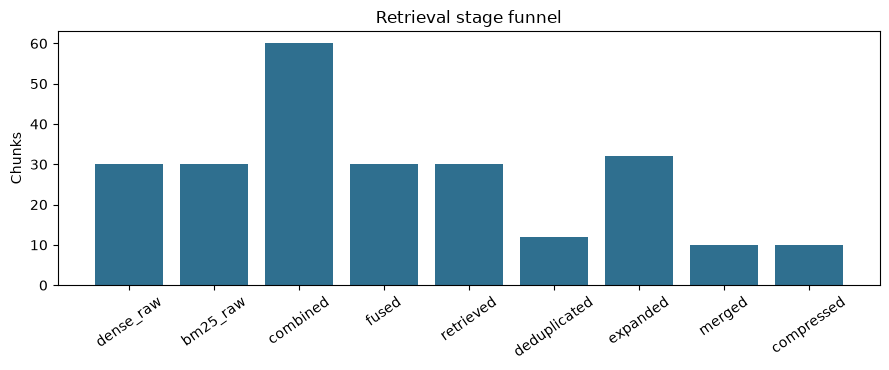

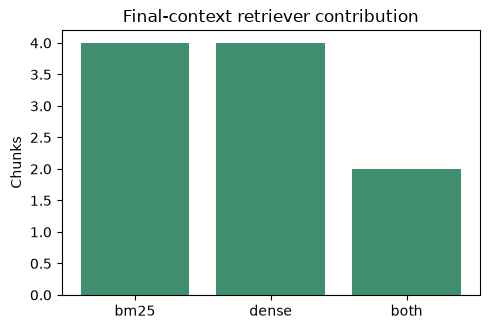

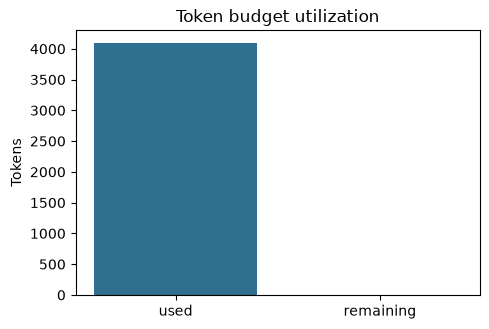

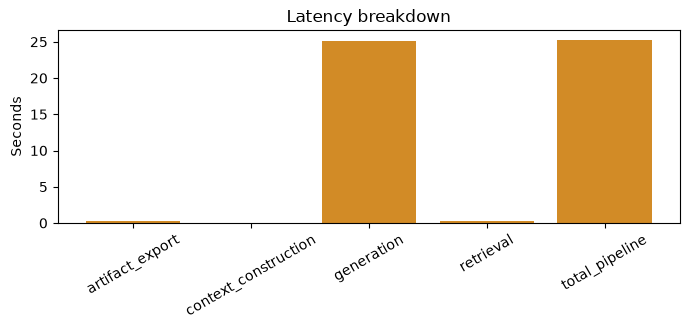

#### Source Diversity

,sources,unique_page_count,unique_source_count
0,"[CISG-2023-01-Information Security Practices for Government Entities.pdf, CISG-2025-02-Comprehensive Cyber Security ...",10,5


#### Decision Summary

,signal,recommendation
0,token_budget,Context is hitting the token budget. Consider lowering retrieval depth or increasing the token budget.
1,bm25_value,BM25 contributed unique final evidence. Hybrid retrieval was useful for this question.
2,retriever_agreement,Dense and BM25 overlap is low. Inspect query transformations or test a larger candidate depth.
3,latency,"Generation is the latency bottleneck. Consider smaller context, lower generation limits, or a shorter answer style."
4,source_diversity,Final context represents 5 unique documents.


In [17]:
TRACE_QUESTION_INDEX = 0
trace_figures = {}

if not question_traces:
    display(Markdown("_No trace available to display._"))
elif not 0 <= TRACE_QUESTION_INDEX < len(question_traces):
    display(
        Markdown(
            f"_TRACE_QUESTION_INDEX must be between 0 and "
            f"{len(question_traces) - 1}._"
        )
    )
else:
    selected_question_trace = question_traces[TRACE_QUESTION_INDEX]
    trace_figures = display_question_trace(selected_question_trace)

## 5. Visualization

Visuals answer engineering questions rather than decorate the notebook:

- Which retriever contributed each candidate?
- How much evidence survived each context stage?
- Did context stay within its configured token budget?
- What latency did each retrieval mode add?
- Which evidence is available for audit?

,membership,chunks
0,bm25+dense,4
1,dense,4
2,bm25,2


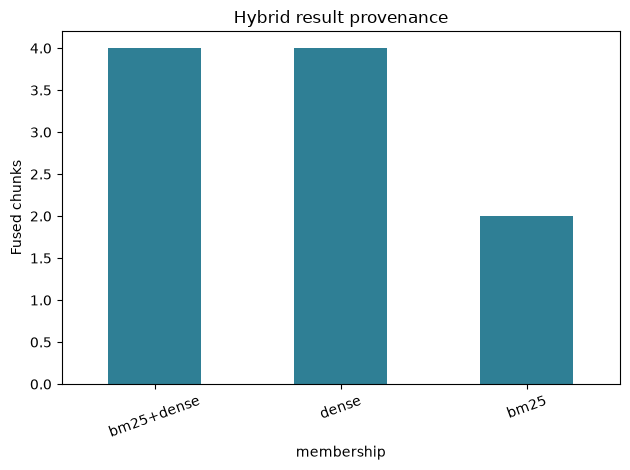

In [18]:
source_membership = pd.Series(
    [
        "+".join(sorted(item.get("retrieval_sources") or ["unknown"]))
        for item in hybrid_results
    ],
    name="retrieval_source_membership",
).value_counts().rename_axis("membership").reset_index(name="chunks")

display(source_membership)
ax = source_membership.set_index("membership")["chunks"].plot.bar(
    title="Hybrid result provenance",
    color="#2f7f95",
)
ax.set_ylabel("Fused chunks")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

,stage,section_count,final_context_characters
0,initial_retrieved_chunks,30,NaN
1,after_deduplication,16,NaN
2,after_neighbor_expansion,44,NaN
3,after_overlap_merging,10,NaN
4,final_context_sections,7,18777.0


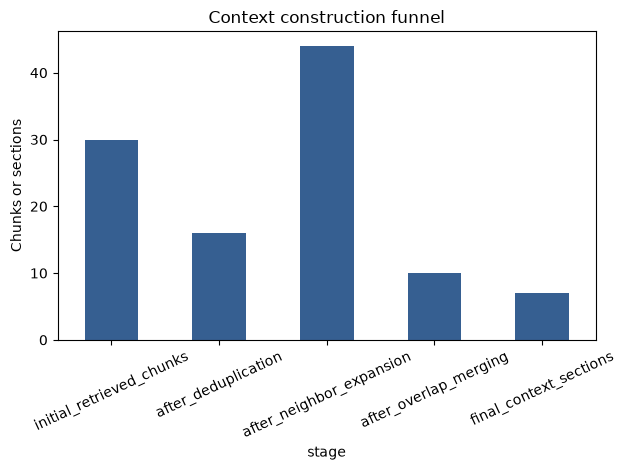

In [19]:
stage_count_table = context_stage_counts_table(context_result)
display(stage_count_table)

ax = stage_count_table.set_index("stage")["section_count"].plot(
    kind="bar",
    title="Context construction funnel",
    color="#365f91",
)
ax.set_ylabel("Chunks or sections")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

,token_metric,value
0,budget,4096
1,used,4095
2,remaining,1
3,context_tokens,4095
4,encoding_name,cl100k_base
5,truncated_sections,1
6,omitted_sections,3
7,budget_type,tokens


,retrieval_mode,seconds
0,bm25,0.002428
1,dense,0.155348
2,hybrid,0.025582


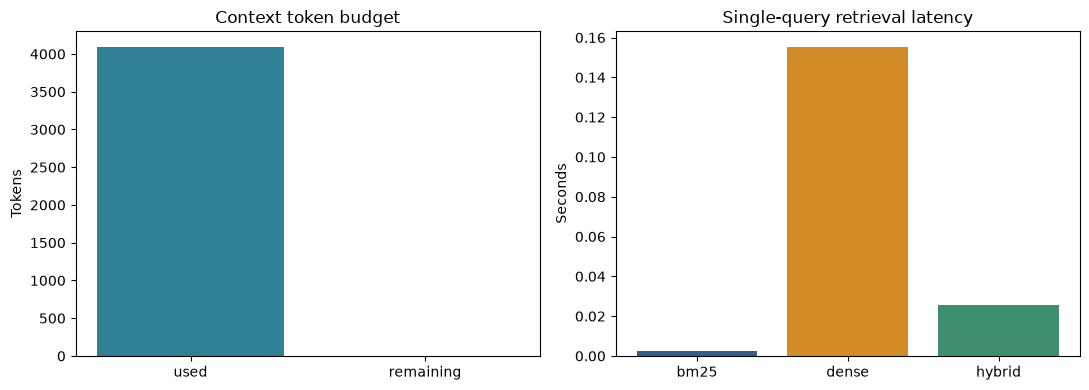

In [20]:
token_usage = (
    response["token_usage"]
    if response is not None
    else {
        "budget": config.max_context_tokens,
        "used": context_tokens,
        "remaining": config.max_context_tokens - context_tokens,
        "context_tokens": context_tokens,
        "encoding_name": pipeline.token_manager.encoding_name,
        "budget_type": "tokens",
    }
)

token_usage_table = pd.DataFrame(
    [(key, value) for key, value in token_usage.items()],
    columns=["token_metric", "value"],
)
latency_table = pd.DataFrame(
    sorted(retrieval_latencies.items()),
    columns=["retrieval_mode", "seconds"],
)

display(token_usage_table)
display(latency_table)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(
    ["used", "remaining"],
    [token_usage["used"], token_usage["remaining"]],
    color=["#2f7f95", "#c9d9de"],
)
axes[0].set_title("Context token budget")
axes[0].set_ylabel("Tokens")
axes[1].bar(
    latency_table["retrieval_mode"],
    latency_table["seconds"],
    color=["#365f91", "#d28b26", "#3f8f6f"],
)
axes[1].set_title("Single-query retrieval latency")
axes[1].set_ylabel("Seconds")
fig.tight_layout()
plt.show()

### 5.1 Dense vs BM25 vs hybrid retrieval smoke comparison

This retrieval-only matrix uses five deliberately different query categories. It is a diagnostic, not a quality score: top-source differences reveal modality behavior, but only benchmark labels and downstream answers can establish correctness.

The comparison changes one typed configuration field at a time and restores it afterward. Loaded documents, embeddings, Qdrant state, and the BM25 index are reused.

In [21]:
comparison_questions = [
    ("semantic paraphrase", "How can systems defend against malicious prompt manipulation?"),
    ("acronym", "Expand AIBOM."),
    ("exact document name", "Where is the SBOM AIBOM HBOM Version 2.0 guideline discussed?"),
    ("regulatory reference", "What does CISG-2026-01 require for incident reporting?"),
    ("unsupported", "What is the approved lunar cargo tariff for CIAL?"),
]


def top_source(results):
    if not results:
        return None
    item = results[0]
    metadata = item.get("metadata") or {}
    page = item.get("page_number") or metadata.get("page_number")
    name = metadata.get("file_name") or item.get("source")
    return f"{name} (p. {page})" if page else str(name)


original_mode = config.retrieval_mode
comparison_rows = []
try:
    for category, question in comparison_questions:
        mode_results = {}
        for mode in ("dense", "bm25", "hybrid"):
            config.retrieval_mode = mode
            pipeline.on_config_changed()
            mode_results[mode] = pipeline.retrieve(question)
        comparison_rows.append(
            {
                "category": category,
                "question": question,
                "dense top source": top_source(mode_results["dense"]),
                "BM25 top source": top_source(mode_results["bm25"]),
                "hybrid top source": top_source(mode_results["hybrid"]),
                "observation": {
                    "semantic paraphrase": "Tests semantic tolerance when exact wording changes.",
                    "acronym": "Tests whether a rare literal term changes the candidate set.",
                    "exact document name": "Tests title-token sensitivity.",
                    "regulatory reference": "Tests an exact framework identifier plus a concept.",
                    "unsupported": "Nearest evidence is not proof of answerability; safe failure remains essential.",
                }[category],
            }
        )
finally:
    config.retrieval_mode = original_mode
    pipeline.on_config_changed()

retrieval_comparison = pd.DataFrame(comparison_rows)
display(retrieval_comparison)

,category,question,dense top source,BM25 top source,hybrid top source,observation
0,semantic paraphrase,How can systems defend against malicious prompt manipulation?,CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf (p. 32),CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf (p. 32),CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf (p. 32),Tests semantic tolerance when exact wording changes.
1,acronym,Expand AIBOM.,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf (p. 58),CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf (p. 46),CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf (p. 59),Tests whether a rare literal term changes the candidate set.
2,exact document name,Where is the SBOM AIBOM HBOM Version 2.0 guideline discussed?,CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf (p. 3),CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf (p. 46),CISG-2024-02- SBOM AIBOM HBOM Version 2.0.pdf (p. 1),Tests title-token sensitivity.
3,regulatory reference,What does CISG-2026-01 require for incident reporting?,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf (p. 25),CISG-2026-02- AI-Assisted Vulnerabilities in Digital Infrastructure.pdf (p. 15),CISG-2026-03- AI-Accelerated Vulnerability Protection & Response.pdf (p. 8),Tests an exact framework identifier plus a concept.
4,unsupported,What is the approved lunar cargo tariff for CIAL?,CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf (p. 29),CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf (p. 36),CISG-2026-01-Cyber Security Framework for Space & Satellite Communication.pdf (p. 36),Nearest evidence is not proof of answerability; safe failure remains essential.


### 5.2 Token-budget experiments

Recommended experiment points are `2048`, `4096`, `6144`, `8192`, `12288`, and `16384` tokens. They span constrained local serving through larger-context analysis without assuming that “more” is automatically better.

The lightweight cell below performs exact tokenizer truncation of the current final context. It answers **capacity** questions only. A full context-quality experiment must rebuild context and generate/evaluate answers at each budget; that expensive sweep belongs in qualification.

In [22]:
recommended_token_budgets = [2048, 4096, 6144, 8192, 12288, 16384]
token_manager = create_token_manager(encoding_name=config.tokenizer_encoding_name)
original_context_tokens = token_manager.count(context_result.context)

token_budget_rows = []
for budget in recommended_token_budgets:
    bounded_context = token_manager.truncate(context_result.context, budget)
    used = token_manager.count(bounded_context)
    token_budget_rows.append(
        {
            "budget": budget,
            "used": used,
            "remaining": budget - used,
            "retained_percent": round(
                100 * used / original_context_tokens,
                2,
            ) if original_context_tokens else 100.0,
            "truncated_in_capacity_demo": original_context_tokens > budget,
            "default_phase3_budget": budget == config.max_context_tokens,
        }
    )

display(pd.DataFrame(token_budget_rows))

,budget,used,remaining,retained_percent,truncated_in_capacity_demo,default_phase3_budget
0,2048,2048,0,50.01,True,False
1,4096,4095,1,100.00,False,True
2,6144,4095,2049,100.00,False,False
3,8192,4095,4097,100.00,False,False
4,12288,4095,8193,100.00,False,False
5,16384,4095,12289,100.00,False,False


### 5.3 Reproducible artifact generation

A `Phase3Runner` run creates the following configured structure:

```text
outputs/
  batch_answers/
    03_Hybrid_Retrieval/
      run_<timestamp>/
        results.csv          # portable row-level data
        results.xlsx         # manager-friendly workbook with PDF hyperlinks
        report.html          # standalone offline review report
        config.json          # effective configuration and run overrides
        summary.json         # executive run summary
        metrics.json         # aggregate quality, token, and latency metrics
        retrieval.json       # query variants, stages, citations, and token traces
        logs.txt              # structured operational events
        figures/             # generated run figures
        context/             # per-question evidence, context, prompt, and answer
```

The one-query smoke run below is **optional** because it performs another local generation call. Set the flag to `True` after the deep-dive generation succeeds. The full bundle is generated by source modules; the notebook only requests the run and displays its tree.

In [23]:
RUN_ARTIFACT_SMOKE = False
run_result = None

if RUN_ARTIFACT_SMOKE:
    run_result = Phase3Runner(pipeline=pipeline, config=config).run(
        questions=[DEEP_DIVE_QUESTION]
    )
    print(f"Generated run directory: {run_result.paths.root}")
    for artifact_path in sorted(run_result.paths.root.rglob("*")):
        relative = artifact_path.relative_to(run_result.paths.root)
        suffix = "/" if artifact_path.is_dir() else ""
        print(f"  {relative}{suffix}")
    display(pd.DataFrame([run_result.summary]))
else:
    expected_root = (
        Path(config.output_root)
        / config.phase_output_name
        / f"{config.run_prefix}_<timestamp>"
    )
    print("Artifact smoke run skipped (RUN_ARTIFACT_SMOKE=False).")
    print(f"Configured run location: {expected_root}")

Artifact smoke run skipped (RUN_ARTIFACT_SMOKE=False).
Configured run location: E:\Adithya A\CIAL-Project\CIAL-Knowledge-OS\outputs\batch_answers\03_Hybrid_Retrieval\run_<timestamp>


## 6. Benchmark

### 6.1 Lightweight smoke-test interpretation

The deep dive and five-query retrieval matrix check execution, trace visibility, exact-term behavior, token enforcement, and mode switching. They do not establish general quality. Before qualification, inspect:

- whether expected source documents appear in each candidate set;
- whether hybrid adds useful evidence rather than only more evidence;
- whether final citations map only to retained context;
- whether unsupported questions safely refuse despite nearest-neighbor candidates;
- whether token budgets omit or truncate important sections; and
- whether retrieval and generation latency remain operationally acceptable.

The current repository status is therefore **implemented / qualification pending**.

### 6.2 Optional: full benchmark qualification

> **Optional: Full benchmark qualification — may take a long time because it calls local Gemma many times.**

The frozen CISG benchmark contains 200 questions. A fair qualification run must use the same approved corpus, embedding model, local LLM, benchmark version, and evaluation rules for dense-only and hybrid modes. At minimum, compare answer accuracy, hallucination rate, citation quality, retrieval latency, total latency, evidence counts, and context tokens.

The gated cell below shows the controlled two-mode sweep. It reuses loaded indexes through `ReconfiguringPipelineFactory`. It does not run unless explicitly enabled, and this notebook does not claim the gate has passed.

In [24]:
RUN_FULL_BENCHMARK = False
qualification_result = None

if RUN_FULL_BENCHMARK:
    frozen_benchmark = load_benchmark(
        config.benchmark_csv_path,
        metadata_path=config.benchmark_metadata_path,
    )
    qualification_runner = ExperimentRunner(
        pipeline_factory=ReconfiguringPipelineFactory(pipeline),
        benchmark=frozen_benchmark,
        output_root=Path(config.output_root) / config.phase_output_name,
    )
    qualification_result = qualification_runner.run(
        ExperimentGrid(
            {
                "retrieval_mode": ["dense", "hybrid"],
                "dense_top_k": [config.dense_top_k],
                "bm25_top_k": [config.bm25_top_k],
                "rrf_k": [config.rrf_k],
                "max_context_tokens": [config.max_context_tokens],
                "neighbor_window": [config.neighbor_window],
            }
        )
    )
    print(qualification_result.dashboard_file)
else:
    print("Full benchmark skipped. Phase 3 remains qualification pending.")

Full benchmark skipped. Phase 3 remains qualification pending.


### 6.3 Qualification decision rule

Do not freeze Phase 3 because one acronym query looks better. Freeze it only after the full artifacts support a documented decision such as:

- hybrid improves exact/acronym/regulatory retrieval and downstream answer metrics without unacceptable hallucination or latency regression; **or**
- hybrid produces a measurable trade-off that justifies a category-specific or configurable deployment policy.

If hybrid increases recall but admits weak candidates, that is evidence for the planned Phase 4 reranker—not permission to hide the regression.

## 7. Advantages

- **Improved candidate recall:** semantic and exact-term signals cover different failure modes.
- **Better acronym and identifier handling:** rare literal strings receive strong lexical weight.
- **Principled fusion:** RRF avoids invalid raw-score averaging and preserves modality provenance.
- **Token-aware context:** one centralized manager enforces and reports context capacity.
- **Evidence navigation:** local PDF page links reduce review friction where browser policy permits.
- **Reproducible run bundles:** CSV, XLSX, HTML, JSON, contexts, figures, and logs preserve the run state.
- **Auditability:** query variants, modality ranks, stage counts, retained evidence, and citations remain inspectable.
- **Backward compatibility:** Phase 2 response keys and evaluation adapters remain available; dense-only mode remains configurable.
- **Offline-first operation:** documents, indexes, tokenization, inference, reports, and logs stay on organization-controlled infrastructure.

## 8. Limitations

- BM25 is lexical; it cannot infer meaning when query and evidence share no useful terms.
- Hybrid retrieval performs more work and may increase latency and memory use.
- RRF fuses ranks but does not estimate relevance or replace a reranker.
- `cl100k_base` is a packaged, deterministic approximation for the configured Gemma runtime, not a Gemma-specific tokenizer.
- `file://` PDF links can be restricted by browser or notebook security policy; localhost mode requires an explicitly configured local document server.
- Retrieval still returns nearest candidates for unsupported questions; safe failure must be validated downstream.
- Full dense-versus-hybrid benchmark qualification has not been completed in this notebook.
- No cross-encoder reranker exists yet.
- No agentic retrieval or multi-hop planner exists yet.
- Retrieval-time authorization and multi-user document isolation remain future production requirements.

## 9. Enterprise Considerations

**Privacy and deployment.** The design remains offline-first: approved PDFs, embeddings, Qdrant, BM25 cache, local LLM calls, tokenizer assets, and reports remain on premises. No cloud inference or hosted vector database is introduced.

**Reproducibility.** Effective configuration, benchmark metadata, mode, candidate depths, RRF constant, token budget, result rows, and run metrics are persisted together. Timestamped run directories never overwrite earlier evidence.

**Auditability and explainability.** A reviewer can move from answer to citation, source page, retained context, query variants, modality ranks, and structured retrieval trace. This makes an answer easier to challenge and reproduce.

**Review usability.** CSV supports analysis, XLSX supports manager workflows and hyperlinks, and standalone HTML supports portable offline review without external scripts. Per-question context files preserve the actual evidence and prompt boundary.

**Security boundary.** Clickable links derive from indexed metadata; they do not implement authorization. Before multi-user deployment, the retrieval layer and document-serving path must enforce approved access controls and document isolation.

## 10. What we'll improve in the next notebook

Phase 3 upgrades CIAL Knowledge OS from dense-only semantic retrieval to a production-style hybrid candidate architecture: deterministic query variants feed dense and BM25 search, RRF creates a unified ranking, Phase 2 post-processing shapes the evidence, token-aware fitting protects context capacity, and linked citations plus run bundles improve reviewability.

Phase 1 and Phase 2 remain frozen. Phase 3 introduces token-aware budgeting only in its own configuration and preserves dense-only compatibility for controlled comparison. It should remain **implemented / qualification pending** until the full unchanged benchmark records the quality, safety, token, and latency trade-offs.

The next phase should focus on **local reranking and precision optimization**: retrieve a broad hybrid candidate pool, use a local cross-encoder or equivalent scorer to promote truly relevant evidence, and measure whether precision gains justify the additional latency.

### Close local resources

Release the embedded Qdrant file lock when the experiment is complete so another notebook or process can reopen the same collection safely.

In [25]:
if getattr(pipeline, "client", None) is not None:
    pipeline.client.close()
    print("Qdrant client closed.")

Qdrant client closed.
